# Processamento Digital de Sinais
## Estudo Dirigido – Parte 4

**Aluno:** Keviny Ryan Menezes Dantas

**Curso:** Engenharia da Computação

**Disciplina:** Processamento Digital de Sinais

**Professor:** Dr. Moacy Pereira da Silva

**Instituição:** Instituto Federal da Paraíba (IFPB)

---

## Objetivos

Este estudo dirigido tem como objetivo aplicar os conceitos fundamentais de Processamento Digital de Sinais (PDS), especialmente aqueles relacionados aos filtros digitais, por meio de experimentos computacionais desenvolvidos em Python utilizando o Google Colab.

As atividades abordam conceitos de:

- Filtragem digital;
- Resposta em frequência;
- Resposta de fase;
- Atraso de grupo;
- Estabilidade de filtros;
- Comparação entre filtros FIR e IIR;
- Aplicações práticas de filtragem digital.

Todas as análises são fundamentadas nos conceitos apresentados por Oppenheim e Schafer na obra *Processamento em Tempo Discreto de Sinais* (2012).

# Questão 1 – Filtragem de um Sinal Composto por Duas Senoides

## Enunciado

Gere um sinal composto pela soma de duas senoides de frequências diferentes. Projete um filtro digital passa-baixa e analise quais componentes espectrais permanecem após a filtragem.

---

## Objetivos da Atividade

- Construir um sinal composto por duas componentes senoidais;
- Projetar um filtro digital passa-baixa;
- Aplicar o filtro ao sinal;
- Comparar o sinal antes e depois da filtragem;
- Analisar o comportamento do filtro no domínio da frequência.

---

## Fundamentação Teórica

Um dos princípios fundamentais do Processamento Digital de Sinais é que qualquer sinal pode ser decomposto em uma combinação de componentes senoidais de diferentes frequências. Para sistemas lineares invariantes no tempo (LIT), cada componente senoidal da entrada produz uma saída de mesma frequência, sofrendo apenas alterações de amplitude e fase.

A resposta em frequência de um filtro descreve precisamente como cada componente espectral é modificada pelo sistema. Em um filtro passa-baixa, as componentes de frequência inferiores à frequência de corte são preservadas, enquanto as componentes de frequência mais elevadas são atenuadas.

Fisicamente, um filtro passa-baixa pode ser interpretado como uma "peneira espectral", permitindo a passagem das frequências de interesse e reduzindo componentes indesejadas, como ruídos de alta frequência.

Neste experimento, será gerado um sinal composto por duas senoides de frequências distintas. Em seguida, será aplicado um filtro passa-baixa para verificar, tanto no domínio do tempo quanto no domínio da frequência, quais componentes permanecem após a filtragem.

In [1]:
# ============================================================
# Questão 1 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [2]:
# ============================================================
# Questão 1 - Geração do Sinal
# ============================================================

fs = 1000          # Frequência de amostragem (Hz)
T = 1              # Duração do sinal (s)

t = np.linspace(0, T, fs, endpoint=False)

f1 = 50            # Primeira senoide (Hz)
f2 = 200           # Segunda senoide (Hz)

x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)

print(f'Frequência de amostragem: {fs} Hz')
print(f'Frequências do sinal: {f1} Hz e {f2} Hz')

Frequência de amostragem: 1000 Hz
Frequências do sinal: 50 Hz e 200 Hz


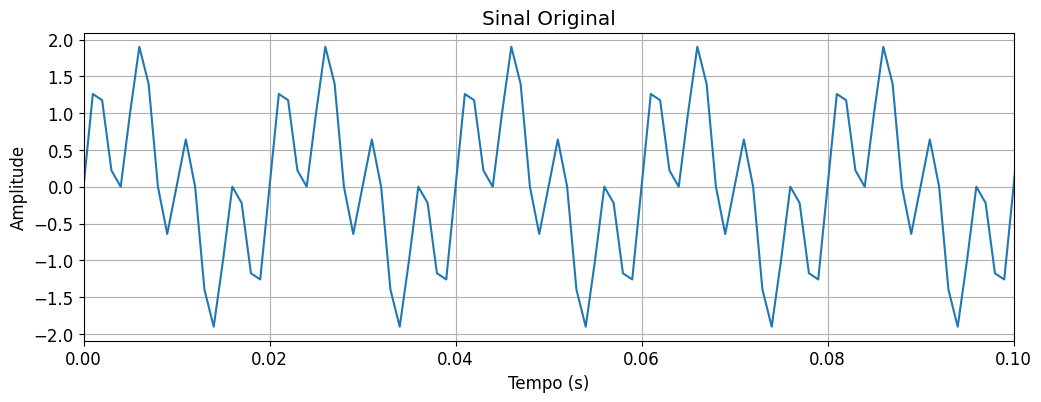

In [3]:
# ============================================================
# Sinal Original
# ============================================================

plt.plot(t, x)

plt.title('Sinal Original')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.1)
plt.grid(True)

plt.show()

In [4]:
# ============================================================
# Projeto do Filtro Passa-Baixa FIR
# ============================================================

fc = 100

b = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

y = signal.lfilter(b, 1, x)

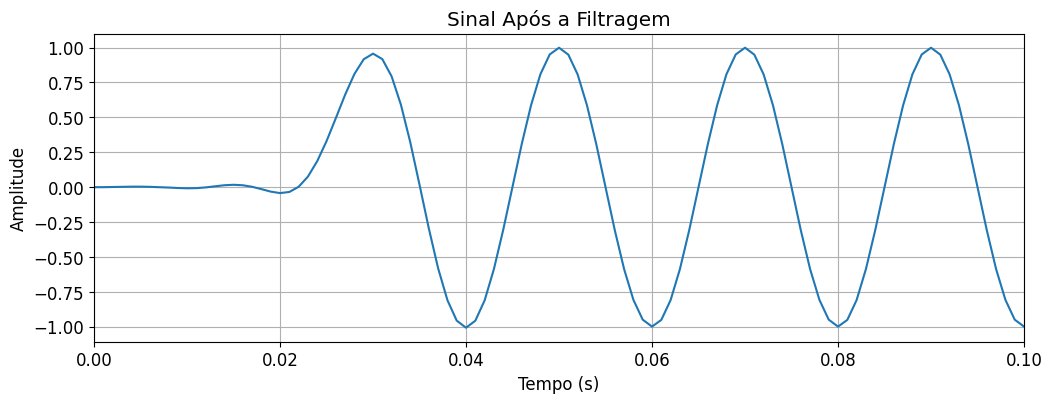

In [5]:
# ============================================================
# Sinal Filtrado
# ============================================================

plt.plot(t, y)

plt.title('Sinal Após a Filtragem')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.1)
plt.grid(True)

plt.show()

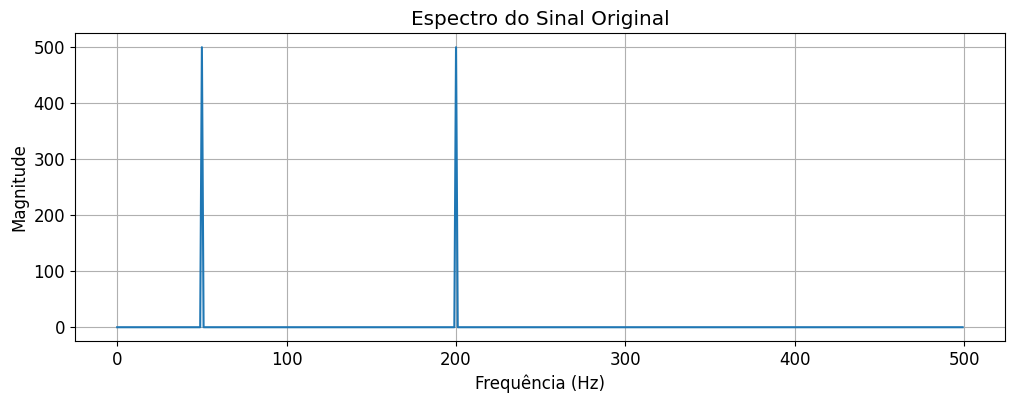

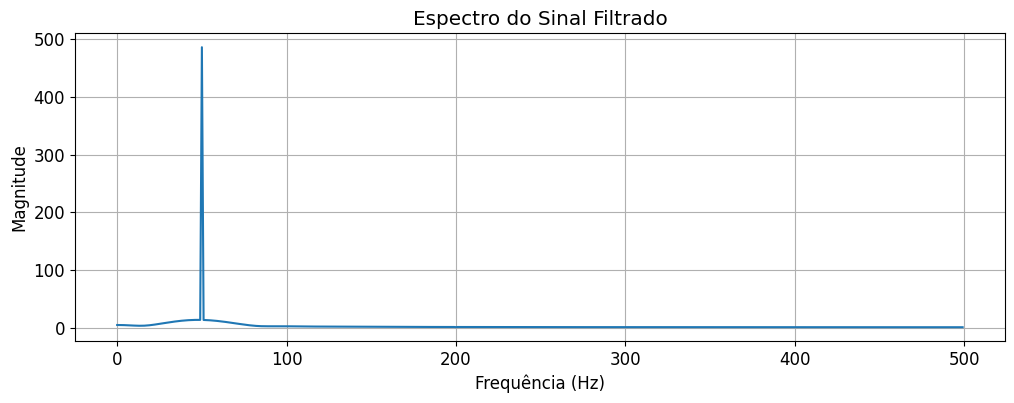

In [6]:
# ============================================================
# Análise Espectral
# ============================================================

N = len(x)

X = fft(x)
Y = fft(y)

freq = fftfreq(N, 1/fs)

plt.figure(figsize=(12,4))
plt.plot(freq[:N//2], np.abs(X[:N//2]))

plt.title('Espectro do Sinal Original')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(freq[:N//2], np.abs(Y[:N//2]))

plt.title('Espectro do Sinal Filtrado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

## Discussão dos Resultados

O espectro do sinal original apresenta duas componentes de frequência claramente identificáveis, localizadas em aproximadamente 50 Hz e 200 Hz.

Após a aplicação do filtro passa-baixa com frequência de corte de 100 Hz, observa-se que a componente de 50 Hz permanece praticamente inalterada, enquanto a componente de 200 Hz sofre forte atenuação.

Esse comportamento está de acordo com a resposta em frequência de um filtro passa-baixa, que apresenta ganho elevado na banda de passagem e ganho reduzido na banda de rejeição. O experimento demonstra, na prática, a interpretação espectral dos sistemas lineares invariantes no tempo, na qual cada componente senoidal é processada individualmente pelo filtro.

A análise realizada evidencia como os filtros digitais podem ser utilizados para separar informações úteis de componentes indesejadas presentes em um sinal, sendo esse princípio amplamente empregado em sistemas de comunicação, instrumentação eletrônica e processamento de sinais provenientes de sensores.

## Conclusão

O filtro digital passa-baixa foi capaz de preservar a componente de baixa frequência do sinal e atenuar significativamente a componente de alta frequência. Os resultados obtidos confirmam a capacidade dos filtros digitais de realizar seleção espectral de sinais, constituindo uma ferramenta fundamental do Processamento Digital de Sinais.

A atividade também permitiu visualizar a relação entre o domínio do tempo e o domínio da frequência, reforçando a importância da resposta em frequência na análise e no projeto de sistemas de filtragem digital.

# Questão 2 – Remoção de Ruído Utilizando um Filtro FIR

## Enunciado

Gere um sinal senoidal contaminado por ruído branco gaussiano. Projete um filtro FIR e aplique-o ao sinal, analisando sua capacidade de reduzir o ruído e preservar a informação útil.

---

## Objetivos da Atividade

- Gerar um sinal senoidal puro;
- Adicionar ruído branco gaussiano ao sinal;
- Projetar um filtro digital FIR passa-baixa;
- Aplicar o filtro ao sinal ruidoso;
- Comparar os sinais antes e após a filtragem;
- Avaliar a eficiência do filtro na redução do ruído;
- Analisar os resultados nos domínios do tempo e da frequência.

---

## Fundamentação Teórica

Na prática, os sinais adquiridos por sensores e sistemas de medição raramente são observados em condições ideais. Geralmente, encontram-se contaminados por diferentes tipos de interferências, sendo o ruído branco gaussiano um dos modelos mais utilizados para representar perturbações aleatórias presentes em sistemas físicos e eletrônicos.

O ruído branco possui energia distribuída ao longo de praticamente todas as frequências do espectro, introduzindo componentes indesejadas que podem dificultar a extração das informações relevantes do sinal.

Uma estratégia amplamente utilizada para reduzir esse tipo de interferência consiste na aplicação de filtros digitais passa-baixa. Quando a informação útil do sinal está concentrada em baixas frequências, o filtro permite a passagem dessas componentes enquanto atenua grande parte do conteúdo de alta frequência associado ao ruído.

Os filtros FIR (Finite Impulse Response) são particularmente adequados para essa tarefa devido à sua estabilidade inerente e à possibilidade de implementação de resposta de fase aproximadamente linear. Segundo Oppenheim e Schafer, filtros FIR podem ser projetados diretamente a partir de uma resposta em frequência desejada, sendo o método do janelamento uma das técnicas mais utilizadas no projeto desses filtros.

Fisicamente, o processo de filtragem pode ser interpretado como uma separação espectral entre o sinal de interesse e as componentes de ruído. Após a filtragem, espera-se obter um sinal mais suave no domínio do tempo e com menor concentração de energia em frequências elevadas, preservando as características fundamentais da informação original.

In [7]:
# ============================================================
# Questão 2 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [8]:
# ============================================================
# Questão 2 - Geração do Sinal com Ruído
# ============================================================

fs = 1000            # Frequência de amostragem (Hz)
T = 1                # Duração (s)

t = np.linspace(0, T, fs, endpoint=False)

f = 20               # Frequência da senoide (Hz)

# Sinal puro
x = np.sin(2*np.pi*f*t)

# Geração do ruído branco gaussiano
np.random.seed(42)
ruido = 0.5 * np.random.randn(len(t))

# Sinal contaminado
x_ruidoso = x + ruido

print(f'Frequência de amostragem: {fs} Hz')
print(f'Frequência do sinal: {f} Hz')

Frequência de amostragem: 1000 Hz
Frequência do sinal: 20 Hz


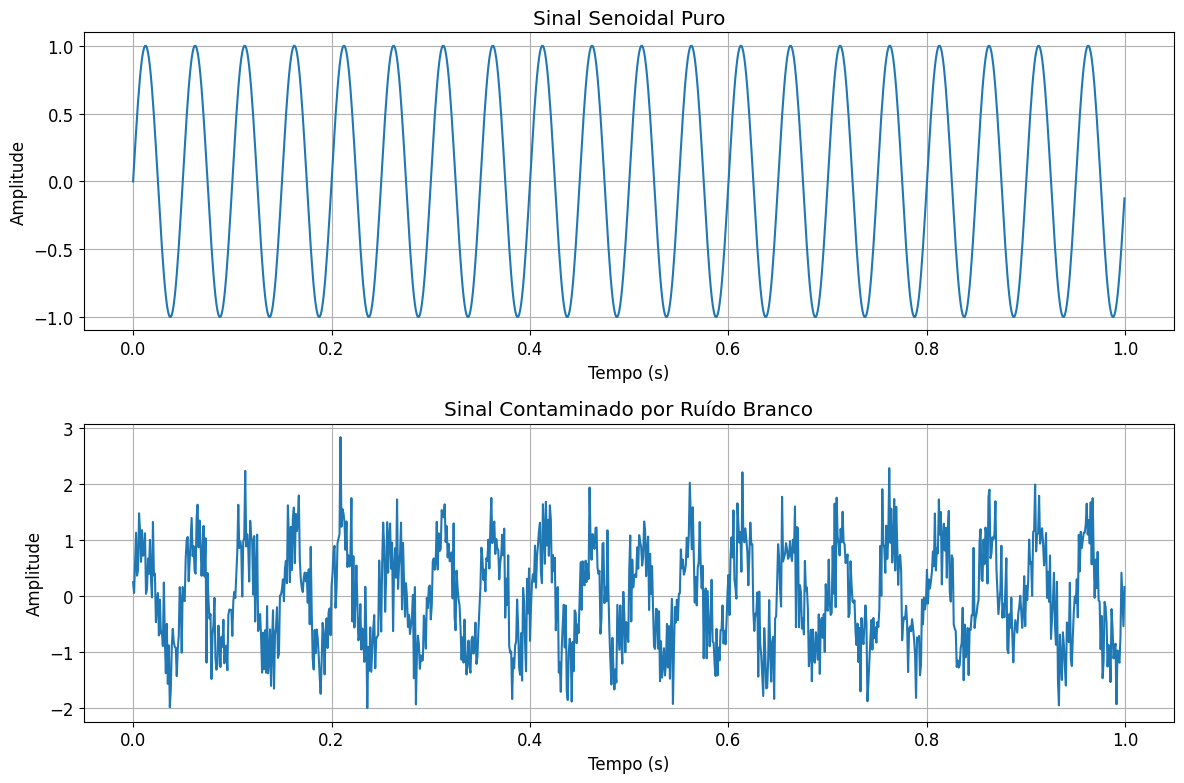

In [9]:
# ============================================================
# Sinal Puro e Sinal com Ruído
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(t, x)
ax[0].set_title('Sinal Senoidal Puro')
ax[0].set_xlabel('Tempo (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)

ax[1].plot(t, x_ruidoso)
ax[1].set_title('Sinal Contaminado por Ruído Branco')
ax[1].set_xlabel('Tempo (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Projeto do Filtro FIR Passa-Baixa
# ============================================================

fc = 50

b = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

In [11]:
# ============================================================
# Aplicação do Filtro
# ============================================================

x_filtrado = signal.lfilter(b, 1, x_ruidoso)

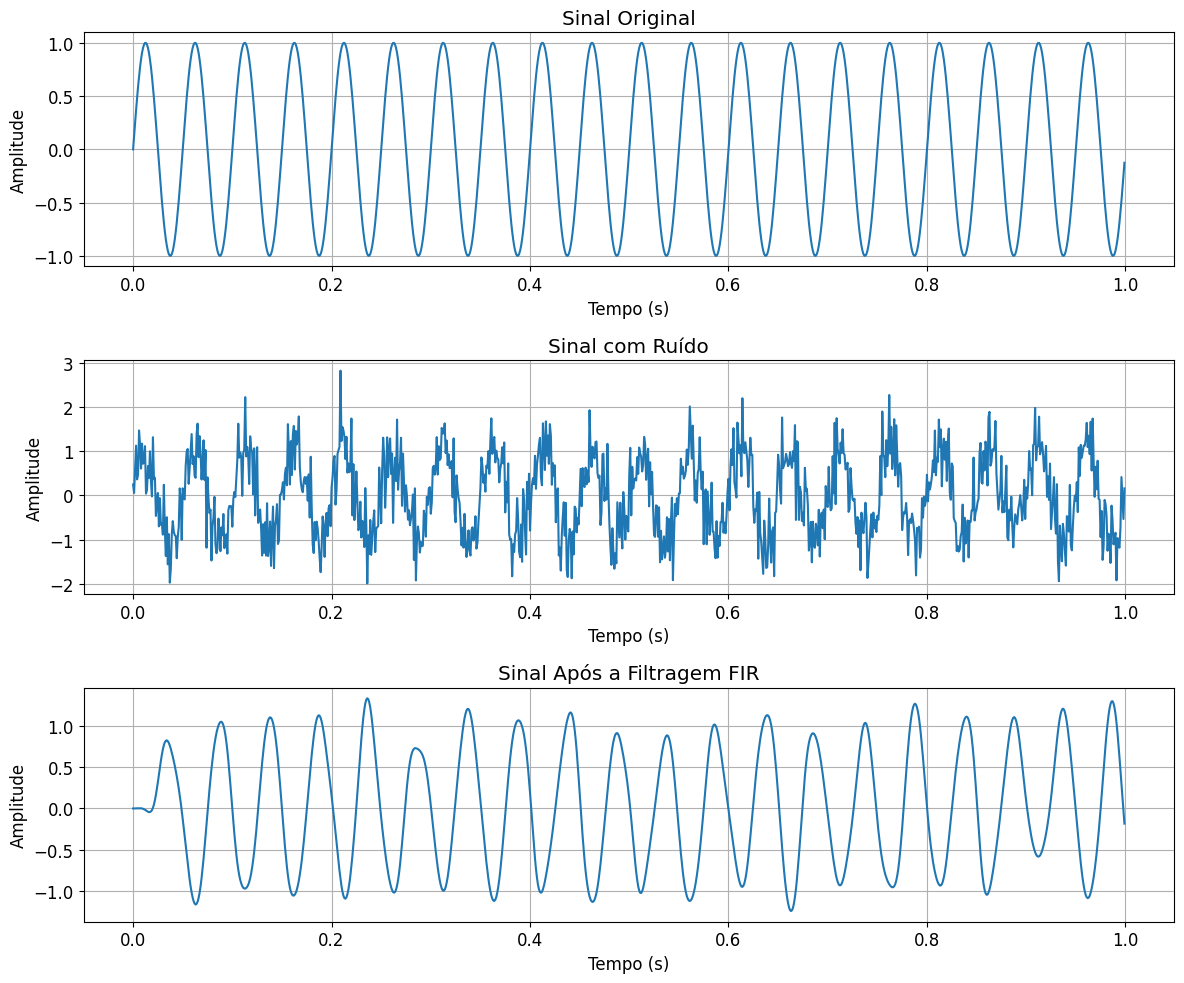

In [12]:
# ============================================================
# Comparação dos Sinais
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')
ax[0].grid(True)

ax[1].plot(t, x_ruidoso)
ax[1].set_title('Sinal com Ruído')
ax[1].grid(True)

ax[2].plot(t, x_filtrado)
ax[2].set_title('Sinal Após a Filtragem FIR')
ax[2].grid(True)

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

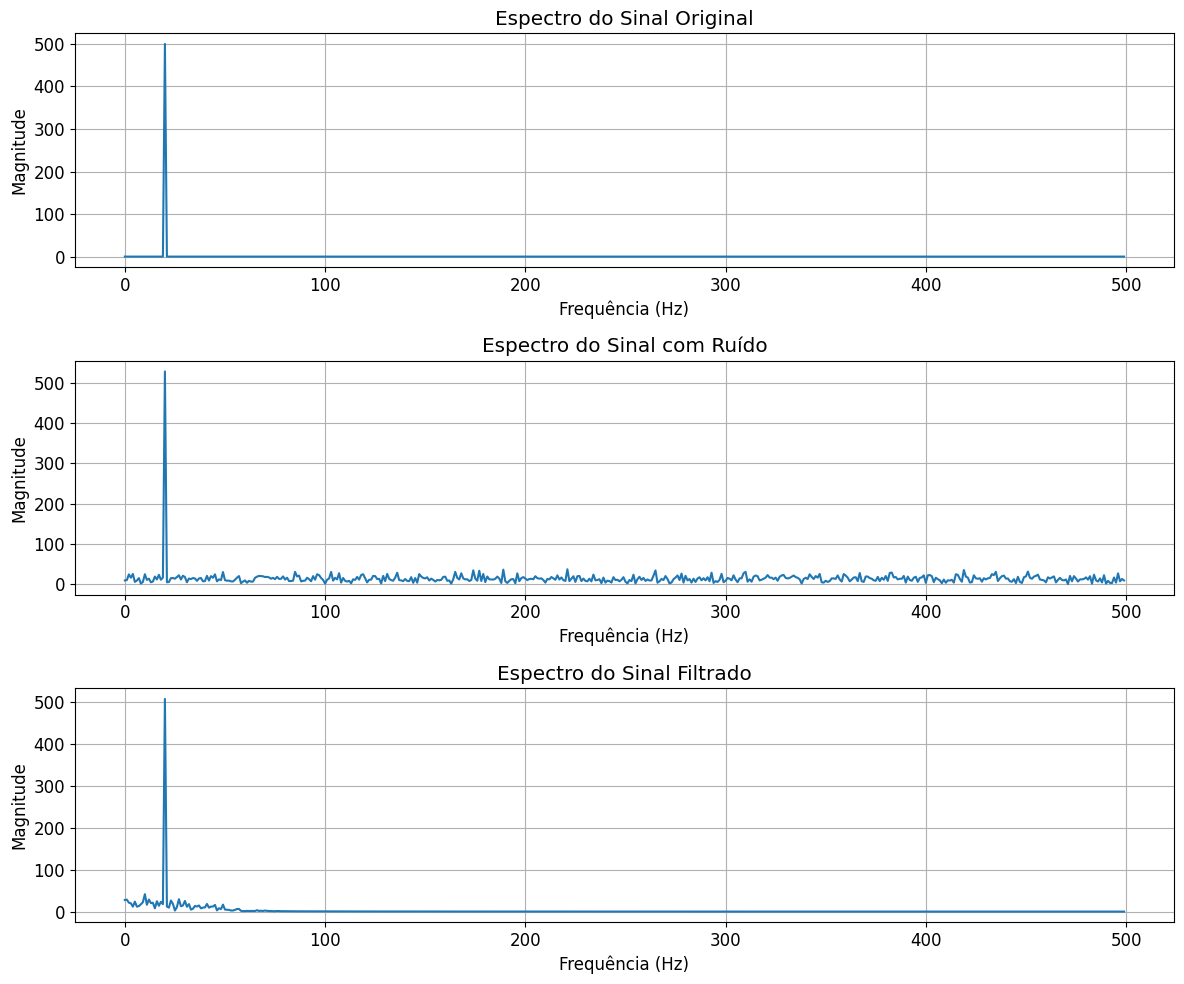

In [13]:
# ============================================================
# Análise Espectral
# ============================================================

N = len(t)
freq = fftfreq(N, 1/fs)

X = fft(x)
XR = fft(x_ruidoso)
XF = fft(x_filtrado)

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(freq[:N//2], np.abs(X[:N//2]))
ax[0].set_title('Espectro do Sinal Original')
ax[0].grid(True)

ax[1].plot(freq[:N//2], np.abs(XR[:N//2]))
ax[1].set_title('Espectro do Sinal com Ruído')
ax[1].grid(True)

ax[2].plot(freq[:N//2], np.abs(XF[:N//2]))
ax[2].set_title('Espectro do Sinal Filtrado')
ax[2].grid(True)

for eixo in ax:
    eixo.set_xlabel('Frequência (Hz)')
    eixo.set_ylabel('Magnitude')

plt.tight_layout()
plt.show()

## Discussão dos Resultados

O sinal original apresenta apenas uma componente espectral localizada em aproximadamente 20 Hz. Após a adição do ruído branco gaussiano, observa-se um aumento significativo da energia distribuída ao longo de diversas frequências, tornando o sinal mais irregular no domínio do tempo.

Após a aplicação do filtro FIR passa-baixa com frequência de corte de 50 Hz, percebe-se uma redução significativa das componentes de alta frequência associadas ao ruído. O sinal resultante torna-se mais suave e sua forma aproxima-se novamente da senoide original.

No domínio da frequência, observa-se que a componente em 20 Hz é preservada, enquanto grande parte da energia espalhada pelo ruído é atenuada pelo filtro. Esse comportamento evidencia a capacidade dos filtros FIR de realizar separação espectral entre a informação útil e as componentes indesejadas.

Em aplicações reais, esse procedimento é amplamente empregado no processamento de sinais provenientes de sensores, sistemas de aquisição de dados, monitoramento ambiental e sistemas embarcados, nos quais a presença de ruído pode comprometer a qualidade das medições e a tomada de decisões.

## Conclusão

A utilização do filtro FIR permitiu reduzir significativamente os efeitos do ruído branco presente no sinal observado. Os resultados obtidos demonstraram que a filtragem passa-baixa é capaz de preservar a componente senoidal de interesse ao mesmo tempo em que atenua as componentes de alta frequência associadas ao ruído.

A atividade evidenciou, na prática, a importância dos filtros digitais no condicionamento de sinais e reforçou os conceitos de resposta em frequência, seletividade espectral e filtragem digital estudados em Processamento Digital de Sinais.

# Questão 3 – Comparação entre Filtros FIR e IIR Butterworth

## Enunciado

Projete um filtro FIR e um filtro IIR do tipo Butterworth para a mesma frequência de corte. Aplique ambos a um sinal contaminado por ruído e compare seus comportamentos, analisando as diferenças entre as respostas obtidas.

---

## Objetivos da Atividade

- Projetar um filtro FIR passa-baixa;
- Projetar um filtro IIR Butterworth passa-baixa;
- Aplicar ambos os filtros a um mesmo sinal ruidoso;
- Comparar os resultados obtidos no domínio do tempo;
- Comparar o desempenho dos filtros na remoção de ruído;
- Identificar vantagens e limitações de cada abordagem de filtragem.

---

## Fundamentação Teórica

Os filtros digitais podem ser classificados em duas grandes categorias: filtros de Resposta ao Impulso Finita (FIR – Finite Impulse Response) e filtros de Resposta ao Impulso Infinita (IIR – Infinite Impulse Response).

Os filtros FIR são caracterizados pela ausência de realimentação. Sua saída depende exclusivamente das amostras atuais e passadas do sinal de entrada. Como consequência, esses filtros são inerentemente estáveis e podem ser projetados de modo a apresentar resposta de fase linear, preservando a forma temporal dos sinais processados.

Por outro lado, os filtros IIR possuem estruturas recursivas, nas quais a saída atual depende tanto das entradas quanto de saídas anteriores. Essa característica permite obter respostas em frequência bastante seletivas utilizando ordens menores quando comparados aos filtros FIR. Entretanto, os filtros IIR geralmente apresentam respostas de fase não linear e exigem cuidados adicionais quanto à estabilidade.

Entre as diversas aproximações utilizadas no projeto de filtros IIR, destaca-se a aproximação Butterworth. Segundo Oppenheim e Schafer, os filtros Butterworth apresentam uma resposta em frequência monotonicamente decrescente, sem oscilações na banda de passagem e na banda de rejeição, sendo frequentemente denominados filtros de resposta maximamente plana.

Fisicamente, a comparação entre filtros FIR e IIR representa um compromisso de projeto. Enquanto os filtros FIR oferecem maior preservação da forma do sinal devido à sua fase aproximadamente linear, os filtros IIR proporcionam maior eficiência computacional e maior seletividade espectral com menor ordem de implementação.

Neste experimento, ambos os filtros serão projetados para a mesma frequência de corte e aplicados ao mesmo sinal ruidoso, permitindo comparar suas características e compreender os compromissos envolvidos na escolha de uma técnica de filtragem digital.

In [14]:
# ============================================================
# Questão 3 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [15]:
# ============================================================
# Questão 3 - Geração do Sinal
# ============================================================

fs = 1000
T = 1

t = np.linspace(0, T, fs, endpoint=False)

# Sinal de interesse
f = 20
x = np.sin(2*np.pi*f*t)

# Ruído branco gaussiano
np.random.seed(42)
ruido = 0.5 * np.random.randn(len(t))

# Sinal contaminado
x_ruidoso = x + ruido

print(f'Frequência de amostragem: {fs} Hz')
print(f'Frequência do sinal: {f} Hz')

Frequência de amostragem: 1000 Hz
Frequência do sinal: 20 Hz


In [16]:
# ============================================================
# Projeto do Filtro FIR
# ============================================================

fc = 50

b_fir = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

In [17]:
# ============================================================
# Projeto do Filtro IIR Butterworth
# ============================================================

ordem = 4

b_iir, a_iir = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

In [18]:
# ============================================================
# Aplicação dos Filtros
# ============================================================

x_fir = signal.lfilter(b_fir, 1, x_ruidoso)

x_iir = signal.lfilter(
    b_iir,
    a_iir,
    x_ruidoso
)

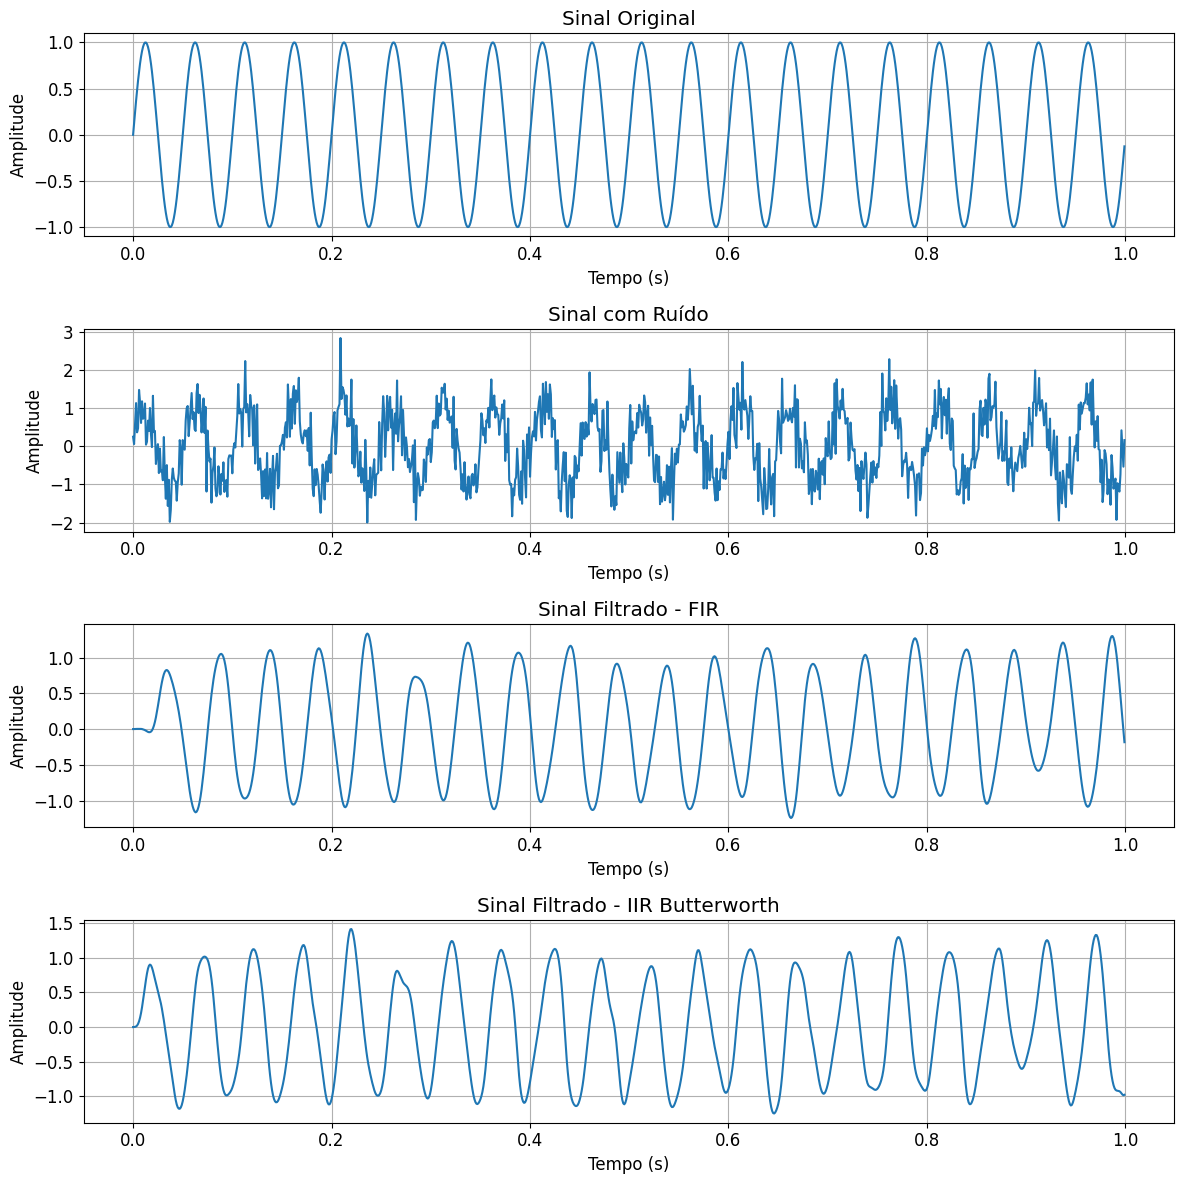

In [19]:
# ============================================================
# Comparação Temporal
# ============================================================

fig, ax = plt.subplots(4, 1, figsize=(12, 12))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')
ax[0].grid(True)

ax[1].plot(t, x_ruidoso)
ax[1].set_title('Sinal com Ruído')
ax[1].grid(True)

ax[2].plot(t, x_fir)
ax[2].set_title('Sinal Filtrado - FIR')
ax[2].grid(True)

ax[3].plot(t, x_iir)
ax[3].set_title('Sinal Filtrado - IIR Butterworth')
ax[3].grid(True)

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

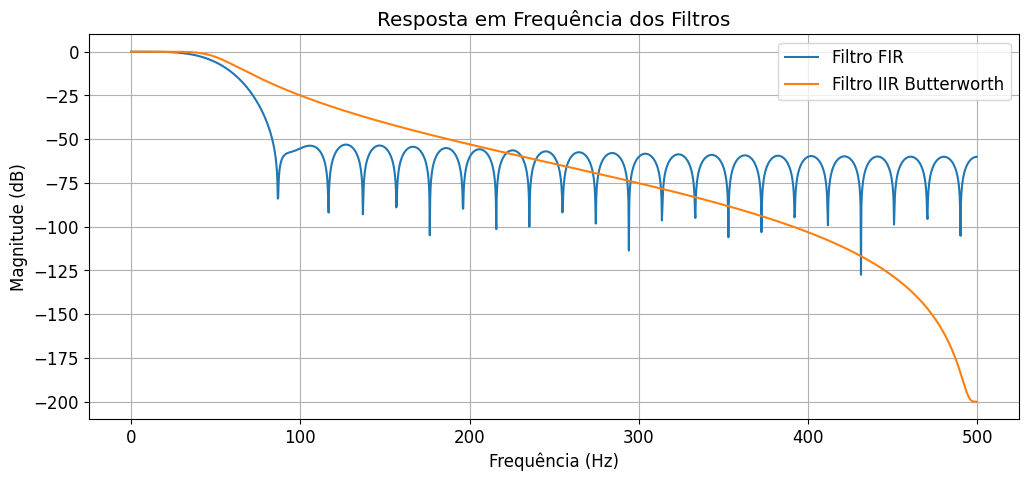

In [20]:
# ============================================================
# Resposta em Frequência
# ============================================================

w_fir, h_fir = signal.freqz(
    b_fir,
    worN=2048,
    fs=fs
)

w_iir, h_iir = signal.freqz(
    b_iir,
    a_iir,
    worN=2048,
    fs=fs
)

plt.figure(figsize=(12,5))

plt.plot(
    w_fir,
    20*np.log10(np.abs(h_fir)+1e-10),
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    20*np.log10(np.abs(h_iir)+1e-10),
    label='Filtro IIR Butterworth'
)

plt.title('Resposta em Frequência dos Filtros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.legend()

plt.show()

## Discussão dos Resultados

Observa-se que ambos os filtros conseguem reduzir significativamente o ruído presente no sinal. Entretanto, existem diferenças importantes entre seus comportamentos.

O filtro FIR produz um sinal mais suavizado e apresenta resposta de fase aproximadamente linear, preservando melhor a forma temporal da senoide original. Essa característica é particularmente desejável em aplicações nas quais a fidelidade temporal do sinal é um requisito importante.

Por sua vez, o filtro IIR Butterworth apresenta uma transição mais abrupta entre a banda de passagem e a banda de rejeição, conseguindo obter elevada seletividade espectral utilizando uma ordem menor de implementação. Além disso, sua resposta em frequência é maximamente plana na banda de passagem, característica típica da aproximação Butterworth.

No entanto, devido à sua natureza recursiva, o filtro IIR apresenta resposta de fase não linear, podendo introduzir distorções temporais no sinal processado.

A atividade evidencia um dos principais compromissos do projeto de filtros digitais: filtros FIR oferecem maior preservação da forma do sinal e estabilidade inerente, enquanto filtros IIR apresentam maior eficiência computacional e melhor seletividade espectral para ordens reduzidas.

## Conclusão

Os resultados demonstraram que tanto o filtro FIR quanto o filtro IIR Butterworth são capazes de reduzir o ruído presente no sinal. Entretanto, cada abordagem apresenta características particulares.

O filtro FIR mostrou-se mais adequado para aplicações que exigem preservação da forma temporal do sinal devido à sua resposta de fase aproximadamente linear e estabilidade inerente. Em contrapartida, o filtro IIR Butterworth apresentou maior seletividade espectral utilizando uma estrutura de menor ordem, sendo uma alternativa computacionalmente mais eficiente.

A atividade permitiu compreender, na prática, os critérios utilizados na escolha entre filtros FIR e IIR em aplicações de Processamento Digital de Sinais, evidenciando os compromissos entre complexidade computacional, seletividade espectral e fidelidade temporal.

# Questão 4 – Comparação das Respostas em Frequência de Filtros FIR e IIR

## Enunciado

Projete um filtro FIR e um filtro IIR Butterworth com a mesma frequência de corte e compare suas respostas em frequência. Analise as diferenças observadas em termos de banda de passagem, banda de transição e atenuação na banda de rejeição.

---

## Objetivos da Atividade

- Projetar um filtro FIR passa-baixa;
- Projetar um filtro IIR Butterworth passa-baixa;
- Obter as respostas em frequência de ambos os filtros;
- Comparar as bandas de passagem e de rejeição;
- Analisar a seletividade espectral de cada filtro;
- Interpretar os resultados sob a perspectiva do Processamento Digital de Sinais.

---

## Fundamentação Teórica

A resposta em frequência de um filtro digital descreve como cada componente espectral de um sinal é modificada ao atravessar o sistema. Para sistemas lineares invariantes no tempo (LIT), cada senoide de frequência específica é multiplicada por um ganho complexo que altera sua amplitude e fase.

A magnitude da resposta em frequência permite identificar quais frequências são preservadas e quais são atenuadas pelo filtro. Em filtros passa-baixa, normalmente são definidas três regiões principais:

- Banda de passagem: faixa de frequências que atravessa o filtro com pequena atenuação;
- Banda de transição: região intermediária na qual o ganho decresce progressivamente;
- Banda de rejeição: faixa de frequências fortemente atenuadas pelo sistema.

Segundo Oppenheim e Schafer, o comportamento da resposta em frequência constitui um dos principais critérios de projeto de filtros digitais, pois determina a capacidade do sistema em separar informações úteis de componentes indesejadas.

Os filtros FIR e IIR apresentam características distintas de seletividade espectral. Filtros FIR geralmente necessitam de ordens mais elevadas para produzir transições abruptas entre as bandas de passagem e rejeição. Em contrapartida, filtros IIR conseguem obter transições mais rápidas utilizando ordens menores, devido à presença de polos em sua função de sistema.

Fisicamente, a resposta em frequência pode ser interpretada como uma curva que indica o nível de "permissão" ou "bloqueio" que o filtro impõe a cada componente de frequência presente no sinal de entrada. Quanto mais abrupta for a transição entre as bandas, maior será a capacidade de separar frequências próximas entre si.

Neste experimento, as respostas em frequência de um filtro FIR e de um filtro IIR Butterworth serão comparadas para evidenciar suas diferenças de seletividade e desempenho espectral.

In [21]:
# ============================================================
# Questão 4 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [22]:
# ============================================================
# Projeto dos Filtros
# ============================================================

fs = 1000
fc = 100

# Filtro FIR
b_fir = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

# Filtro IIR Butterworth
ordem = 4

b_iir, a_iir = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

print('Filtros projetados com sucesso.')

Filtros projetados com sucesso.


In [23]:
# ============================================================
# Resposta em Frequência
# ============================================================

w_fir, h_fir = signal.freqz(
    b_fir,
    worN=2048,
    fs=fs
)

w_iir, h_iir = signal.freqz(
    b_iir,
    a_iir,
    worN=2048,
    fs=fs
)

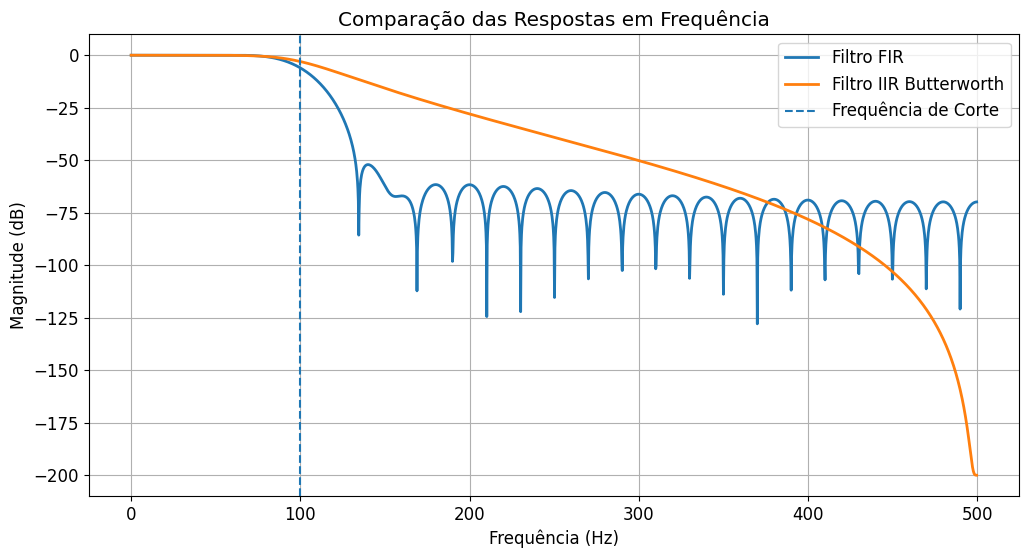

In [24]:
# ============================================================
# Comparação das Magnitudes
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    w_fir,
    20*np.log10(np.abs(h_fir)+1e-10),
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    20*np.log10(np.abs(h_iir)+1e-10),
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.axvline(
    fc,
    linestyle='--',
    label='Frequência de Corte'
)

plt.title('Comparação das Respostas em Frequência')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.legend()

plt.show()

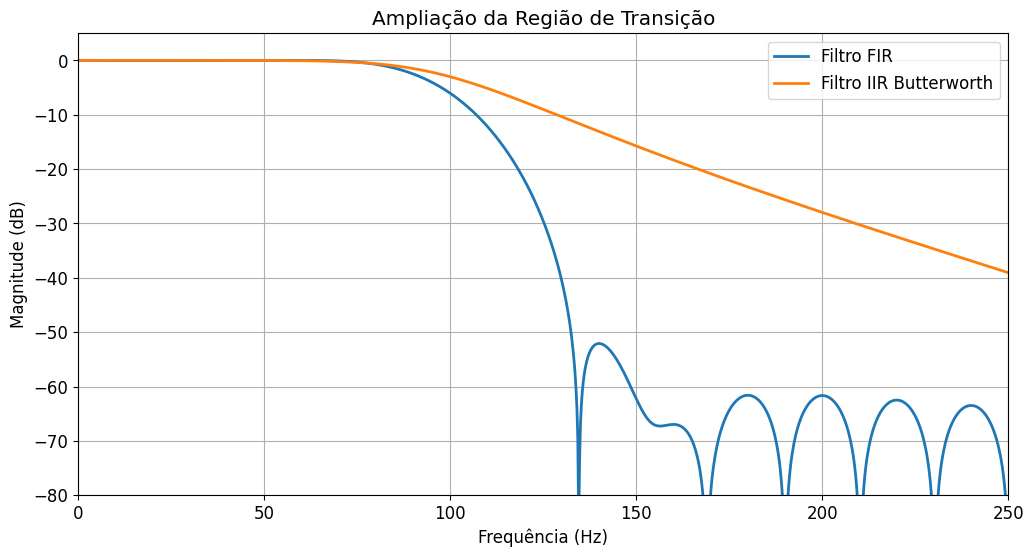

In [25]:
# ============================================================
# Região de Transição
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    w_fir,
    20*np.log10(np.abs(h_fir)+1e-10),
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    20*np.log10(np.abs(h_iir)+1e-10),
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.xlim(0, 250)
plt.ylim(-80, 5)

plt.title('Ampliação da Região de Transição')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.legend()

plt.show()

## Discussão dos Resultados

Os gráficos obtidos permitem observar diferenças significativas entre os dois tipos de filtros.

O filtro FIR apresenta uma transição mais gradual entre a banda de passagem e a banda de rejeição. Isso ocorre porque filtros FIR geralmente necessitam de um número maior de coeficientes para produzir transições mais abruptas.

Por outro lado, o filtro IIR Butterworth apresenta uma região de transição mais estreita, conseguindo atenuar as componentes de alta frequência de maneira mais rápida. Essa característica decorre da presença de polos na função de sistema, que permite obter elevada seletividade espectral com ordens relativamente baixas.

Observa-se ainda que a resposta Butterworth apresenta comportamento monotonicamente decrescente, sem oscilações na banda de passagem e na banda de rejeição, sendo frequentemente denominada resposta maximamente plana.

Do ponto de vista do Processamento Digital de Sinais, a análise da resposta em frequência evidencia um importante compromisso de projeto. Filtros FIR oferecem maior flexibilidade para obtenção de respostas de fase linear, porém normalmente exigem ordens maiores. Já os filtros IIR conseguem elevada seletividade utilizando menor complexidade computacional, embora apresentem respostas de fase não lineares.

## Conclusão

A comparação das respostas em frequência mostrou que ambos os filtros realizam a função de filtragem passa-baixa, porém apresentam características espectrais distintas.

O filtro FIR apresentou uma transição mais gradual entre as bandas de passagem e rejeição, enquanto o filtro IIR Butterworth apresentou maior seletividade espectral e uma transição mais abrupta utilizando uma estrutura de menor ordem.

A atividade permitiu compreender a importância da resposta em frequência no projeto de filtros digitais e evidenciou os compromissos existentes entre seletividade, complexidade computacional e fidelidade temporal dos sinais processados.

# Questão 5 – Análise de Polos e Zeros de um Filtro IIR

## Enunciado

Projete um filtro IIR do tipo Butterworth e determine a localização de seus polos e zeros no plano-z. Analise a relação entre a distribuição dos polos e zeros e o comportamento da resposta em frequência do filtro.

---

## Objetivos da Atividade

- Projetar um filtro digital IIR Butterworth passa-baixa;
- Determinar os polos e zeros da função de sistema;
- Representar graficamente polos e zeros no plano-z;
- Relacionar a posição dos polos e zeros com a resposta em frequência do filtro;
- Verificar a condição de estabilidade do sistema;
- Interpretar fisicamente o comportamento do filtro.

---

## Fundamentação Teórica

Em Processamento Digital de Sinais, os sistemas lineares invariantes no tempo podem ser representados pela sua função de sistema no domínio-z, geralmente expressa como uma razão entre dois polinômios:

H(z) = B(z) / A(z)

As raízes do numerador são denominadas zeros, enquanto as raízes do denominador são denominadas polos.

Segundo Oppenheim e Schafer, a localização dos polos e zeros no plano-z fornece informações fundamentais sobre o comportamento do sistema, incluindo sua resposta em frequência e sua estabilidade.

Os zeros podem ser interpretados como regiões do plano-z nas quais determinadas componentes de frequência são atenuadas ou completamente eliminadas. Já os polos representam regiões onde a resposta do sistema tende a ser amplificada.

Para sistemas causais e estáveis, todos os polos devem estar localizados estritamente no interior da circunferência unitária. Caso algum polo esteja sobre ou fora da circunferência unitária, a resposta ao impulso do sistema torna-se ilimitada, caracterizando um sistema instável.

Em filtros IIR Butterworth, os polos distribuem-se de maneira simétrica no interior da circunferência unitária, produzindo uma resposta em frequência monotonicamente decrescente e maximamente plana na banda de passagem.

Fisicamente, pode-se interpretar os polos como elementos responsáveis pela seletividade do filtro. Quanto mais próximos da circunferência unitária, mais pronunciados tendem a ser seus efeitos sobre determinadas regiões espectrais. Por outro lado, os zeros podem ser vistos como mecanismos de supressão de frequências específicas.

Neste experimento, será projetado um filtro IIR Butterworth e será analisada a relação entre a distribuição de polos e zeros e as características observadas em sua resposta em frequência.

In [26]:
# ============================================================
# Questão 5 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['font.size'] = 12

In [27]:
# ============================================================
# Projeto do Filtro IIR Butterworth
# ============================================================

fs = 1000
fc = 100
ordem = 4

b, a = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

print("Coeficientes do Numerador (b):")
print(b)

print("\nCoeficientes do Denominador (a):")
print(a)

Coeficientes do Numerador (b):
[0.00482434 0.01929737 0.02894606 0.01929737 0.00482434]

Coeficientes do Denominador (a):
[ 1.         -2.36951301  2.31398841 -1.05466541  0.18737949]


In [28]:
# ============================================================
# Cálculo dos Polos e Zeros
# ============================================================

zeros = np.roots(b)
polos = np.roots(a)

print("Zeros:")
print(zeros)

print("\nPolos:")
print(polos)

Zeros:
[-1.00021915+0.j         -0.99999998+0.00021913j -0.99999998-0.00021913j
 -0.99978088+0.j        ]

Polos:
[0.66045672+0.44332349j 0.66045672-0.44332349j 0.52429979+0.1457741j
 0.52429979-0.1457741j ]


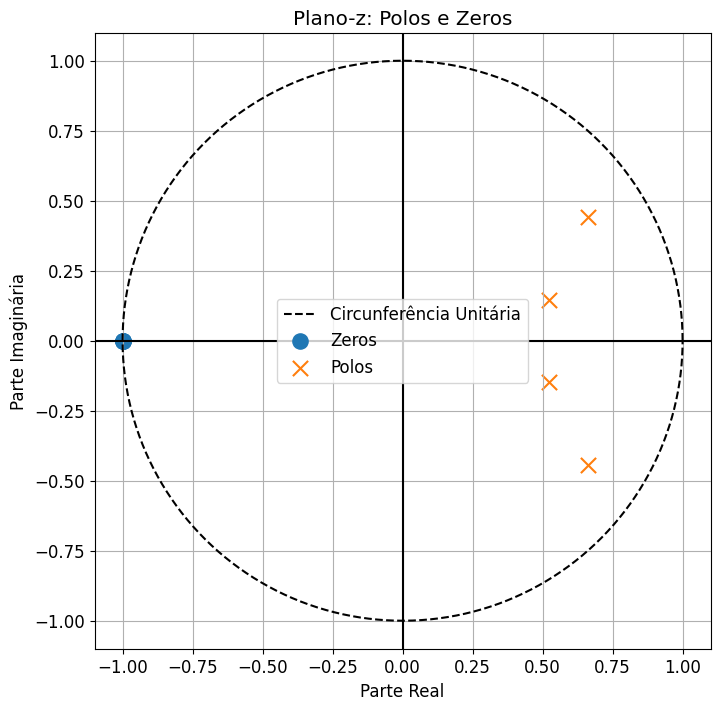

In [29]:
# ============================================================
# Diagrama de Polos e Zeros
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

angulo = np.linspace(0, 2*np.pi, 1000)

ax.plot(
    np.cos(angulo),
    np.sin(angulo),
    'k--',
    label='Circunferência Unitária'
)

ax.scatter(
    np.real(zeros),
    np.imag(zeros),
    marker='o',
    s=120,
    label='Zeros'
)

ax.scatter(
    np.real(polos),
    np.imag(polos),
    marker='x',
    s=120,
    label='Polos'
)

ax.axhline(0, color='black')
ax.axvline(0, color='black')

ax.set_title('Plano-z: Polos e Zeros')
ax.set_xlabel('Parte Real')
ax.set_ylabel('Parte Imaginária')

ax.grid(True)
ax.legend()
ax.set_aspect('equal')

plt.show()

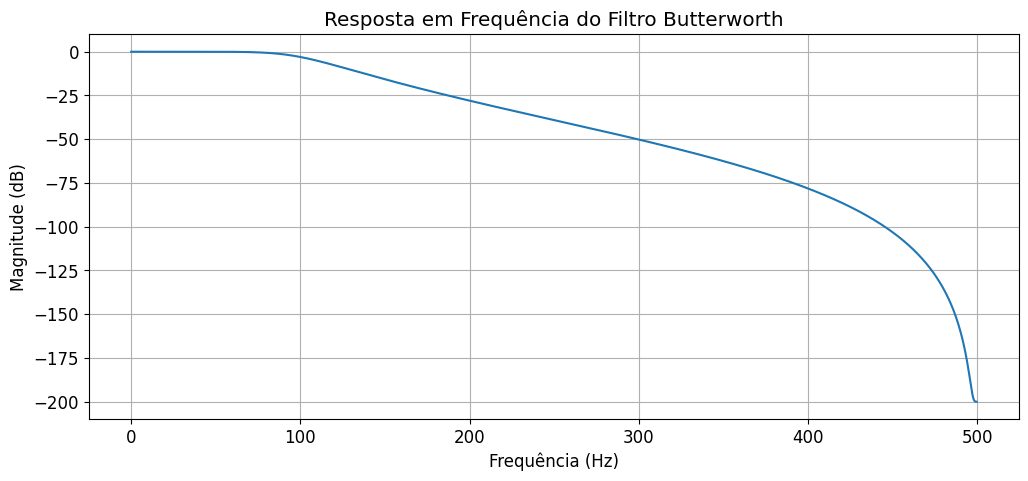

In [30]:
# ============================================================
# Resposta em Frequência
# ============================================================

w, h = signal.freqz(
    b,
    a,
    worN=2048,
    fs=fs
)

plt.figure(figsize=(12, 5))

plt.plot(
    w,
    20*np.log10(np.abs(h) + 1e-10)
)

plt.title('Resposta em Frequência do Filtro Butterworth')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.show()

In [31]:
# ============================================================
# Verificação da Estabilidade
# ============================================================

modulos = np.abs(polos)

print("Módulo dos polos:")
print(modulos)

if np.all(modulos < 1):
    print("\nO filtro é estável.")
else:
    print("\nO filtro é instável.")

Módulo dos polos:
[0.7954488 0.7954488 0.5441878 0.5441878]

O filtro é estável.


## Discussão dos Resultados

O diagrama de polos e zeros mostra que todos os polos encontram-se localizados no interior da circunferência unitária. De acordo com a teoria de sistemas discretos, essa condição garante que o filtro seja causal e estável.

Observa-se ainda que os polos distribuem-se em pares complexos conjugados, característica típica dos filtros Butterworth. Essa configuração produz uma resposta em frequência suavemente decrescente e sem oscilações na banda de passagem.

Os zeros encontram-se posicionados de forma a contribuir para a atenuação das componentes de alta frequência. Já a proximidade dos polos em relação à circunferência unitária influencia diretamente a seletividade espectral do filtro.

A resposta em frequência obtida confirma esse comportamento, apresentando ganho elevado para baixas frequências e forte atenuação nas frequências mais altas.

Do ponto de vista físico, o experimento evidencia que a posição geométrica dos polos e zeros no plano-z determina diretamente as características de filtragem do sistema. Dessa forma, o plano-z torna-se uma poderosa ferramenta de análise e projeto de filtros digitais.

## Conclusão

A atividade permitiu compreender a importância da representação de sistemas digitais no domínio-z e sua relação direta com a resposta em frequência.

Foi verificado que o filtro IIR Butterworth apresenta todos os seus polos no interior da circunferência unitária, garantindo estabilidade. Além disso, a distribuição dos polos e zeros explica o comportamento espectral observado, caracterizado por uma resposta passa-baixa suave e monotonicamente decrescente.

O estudo de polos e zeros constitui uma etapa fundamental no projeto de filtros digitais, pois permite prever características de estabilidade, seletividade e desempenho espectral antes mesmo da implementação prática do sistema.

# Questão 6 – Comparação das Respostas ao Impulso de Filtros FIR e IIR

## Enunciado

Projete um filtro FIR e um filtro IIR Butterworth e determine suas respostas ao impulso. Compare os resultados obtidos e analise as diferenças entre os comportamentos temporais de cada filtro.

---

## Objetivos da Atividade

- Projetar um filtro digital FIR passa-baixa;
- Projetar um filtro digital IIR Butterworth passa-baixa;
- Determinar a resposta ao impulso de ambos os filtros;
- Comparar as características temporais das respostas obtidas;
- Relacionar a resposta ao impulso com a estrutura matemática de cada filtro;
- Interpretar fisicamente as diferenças entre filtros FIR e IIR.

---

## Fundamentação Teórica

A resposta ao impulso é uma das características mais importantes dos sistemas lineares invariantes no tempo (LIT). Ela corresponde à saída produzida pelo sistema quando a entrada é um impulso unitário discreto, definido como uma sequência que assume valor unitário em uma única amostra e valor nulo em todas as demais.

Segundo Oppenheim e Schafer, a resposta ao impulso caracteriza completamente um sistema LIT, pois qualquer saída do sistema pode ser determinada pela convolução entre o sinal de entrada e a resposta ao impulso do sistema.

Nos filtros FIR (Finite Impulse Response), a resposta ao impulso possui duração finita. Isso ocorre porque a saída depende apenas das amostras presentes e passadas da entrada, não existindo mecanismos de realimentação interna. Após um número finito de amostras, a influência do impulso desaparece completamente.

Em contraste, os filtros IIR (Infinite Impulse Response) apresentam estruturas recursivas, nas quais a saída atual depende também de saídas anteriores. Como consequência, um único impulso aplicado na entrada produz efeitos que persistem ao longo do tempo, gerando uma resposta ao impulso teoricamente infinita.

Fisicamente, a resposta ao impulso pode ser interpretada como a "assinatura temporal" do filtro. Ela descreve como o sistema reage a uma excitação instantânea e revela propriedades importantes, como estabilidade, memória e comportamento transitório.

Neste experimento, serão determinadas as respostas ao impulso de um filtro FIR e de um filtro IIR Butterworth, permitindo visualizar diretamente os efeitos da ausência e da presença de realimentação nos sistemas de filtragem digital.

In [32]:
# ============================================================
# Questão 6 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [33]:
# ============================================================
# Projeto dos Filtros
# ============================================================

fs = 1000
fc = 100

# Filtro FIR
b_fir = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

# Filtro IIR Butterworth
ordem = 4

b_iir, a_iir = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

print('Filtros projetados com sucesso.')

Filtros projetados com sucesso.


In [34]:
# ============================================================
# Geração do Impulso Unitário
# ============================================================

N = 100

impulso = np.zeros(N)
impulso[0] = 1

n = np.arange(N)

In [35]:
# ============================================================
# Resposta ao Impulso - FIR
# ============================================================

h_fir = signal.lfilter(
    b_fir,
    1,
    impulso
)

In [36]:
# ============================================================
# Resposta ao Impulso - IIR
# ============================================================

h_iir = signal.lfilter(
    b_iir,
    a_iir,
    impulso
)

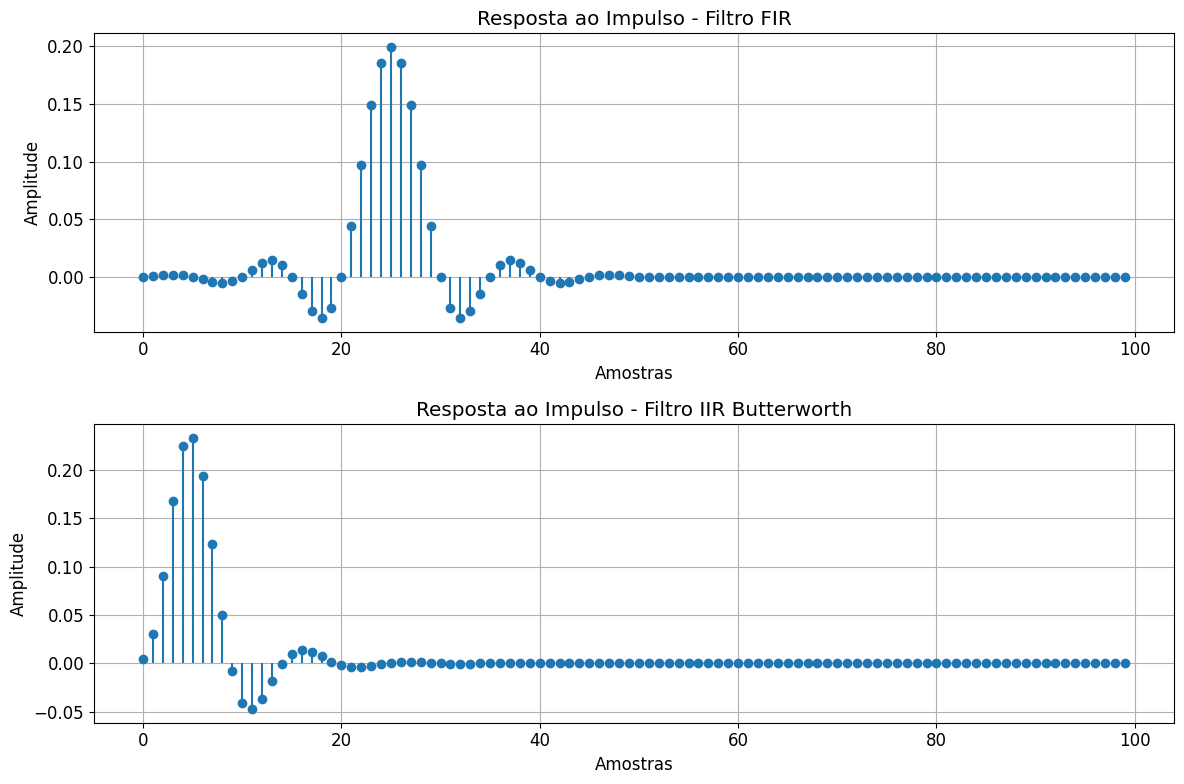

In [37]:
# ============================================================
# Comparação das Respostas ao Impulso
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].stem(
    n,
    h_fir,
    basefmt=' '
)
ax[0].set_title('Resposta ao Impulso - Filtro FIR')
ax[0].set_xlabel('Amostras')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)

ax[1].stem(
    n,
    h_iir,
    basefmt=' '
)
ax[1].set_title('Resposta ao Impulso - Filtro IIR Butterworth')
ax[1].set_xlabel('Amostras')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)

plt.tight_layout()
plt.show()

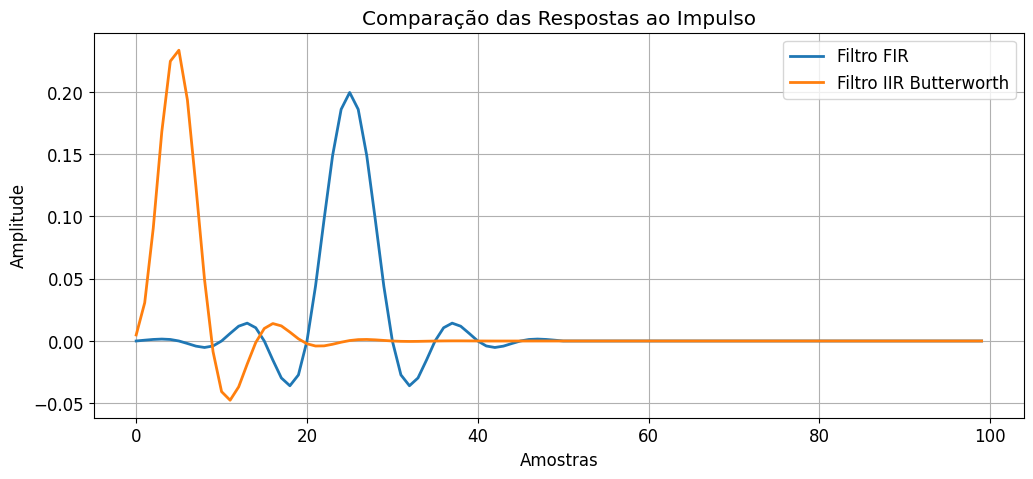

In [38]:
# ============================================================
# Comparação Direta
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    n,
    h_fir,
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    n,
    h_iir,
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.title('Comparação das Respostas ao Impulso')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.grid(True)
plt.legend()

plt.show()

## Discussão dos Resultados

Observa-se que a resposta ao impulso do filtro FIR possui duração limitada. Após um número finito de amostras, a resposta torna-se nula, evidenciando a ausência de mecanismos de realimentação interna.

Por outro lado, o filtro IIR Butterworth apresenta uma resposta que decai gradualmente ao longo do tempo, mas não se anula imediatamente. Isso ocorre porque a estrutura recursiva do sistema faz com que cada saída influencie as amostras subsequentes, produzindo uma resposta teoricamente infinita.

Embora a resposta do filtro IIR tenda a valores muito próximos de zero após certo intervalo de tempo, pequenas contribuições continuam existindo devido ao efeito de memória do sistema.

Do ponto de vista físico, a resposta ao impulso permite interpretar o comportamento dinâmico dos filtros. O filtro FIR reage ao impulso de maneira limitada e previsível, enquanto o filtro IIR apresenta um comportamento transitório mais prolongado em virtude de sua realimentação interna.

Os resultados obtidos demonstram claramente a principal diferença estrutural entre filtros FIR e IIR, justificando suas denominações de resposta ao impulso finita e resposta ao impulso infinita.

## Conclusão

A análise das respostas ao impulso permitiu visualizar diretamente as diferenças fundamentais entre filtros FIR e IIR.

O filtro FIR apresentou uma resposta de duração finita, consequência direta de sua estrutura não recursiva. Em contraste, o filtro IIR Butterworth apresentou uma resposta que persiste ao longo do tempo devido à presença de realimentação interna.

A atividade mostrou que a resposta ao impulso constitui uma poderosa ferramenta de análise de sistemas digitais, permitindo compreender propriedades importantes como memória, comportamento transitório e estabilidade.

Além disso, os resultados reforçam os conceitos teóricos apresentados por Oppenheim e Schafer, evidenciando a relação direta entre a estrutura matemática dos filtros e seus comportamentos temporais.

# Questão 7 – Projeto de um Filtro Digital Passa-Faixa

## Enunciado

Gere um sinal composto por múltiplas senoides de diferentes frequências. Projete um filtro digital passa-faixa e analise sua capacidade de selecionar apenas as componentes espectrais pertencentes à banda de frequências desejada.

---

## Objetivos da Atividade

- Gerar um sinal composto por diversas componentes senoidais;
- Projetar um filtro digital passa-faixa;
- Aplicar o filtro ao sinal composto;
- Comparar o sinal antes e após a filtragem;
- Analisar os resultados nos domínios do tempo e da frequência;
- Verificar a capacidade do filtro em isolar uma faixa específica de frequências.

---

## Fundamentação Teórica

Os filtros digitais podem ser classificados de acordo com as regiões espectrais que permitem atravessar o sistema. Entre essas categorias, destacam-se os filtros passa-faixa, cuja principal característica consiste em permitir a passagem de componentes localizadas em uma faixa intermediária de frequências, atenuando componentes abaixo e acima dessa região.

Segundo Oppenheim e Schafer, a resposta em frequência de um sistema descreve como cada componente senoidal é modificada em magnitude e fase ao atravessar o filtro. Em um filtro passa-faixa, a resposta em frequência apresenta ganho elevado dentro da banda de interesse e ganho reduzido fora dessa região.

Fisicamente, um filtro passa-faixa pode ser interpretado como uma janela espectral. Diferentemente de um filtro passa-baixa, que permite a passagem de todas as frequências inferiores à frequência de corte, o filtro passa-faixa seleciona apenas uma região específica do espectro, funcionando como um mecanismo de isolamento de determinadas componentes de frequência.

Esse tipo de filtragem possui diversas aplicações práticas, incluindo sistemas de telecomunicações, processamento de sinais biomédicos, instrumentação eletrônica e monitoramento de vibrações mecânicas. Em sistemas de monitoramento ambiental e agrícola, filtros passa-faixa podem ser empregados para identificar padrões periódicos específicos presentes nos sinais provenientes de sensores.

Neste experimento, será gerado um sinal composto por várias senoides de frequências distintas. Em seguida, será projetado um filtro passa-faixa para selecionar apenas as componentes pertencentes à faixa de frequências desejada, permitindo analisar o comportamento do sistema nos domínios do tempo e da frequência.

In [39]:
# ============================================================
# Questão 7 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [40]:
# ============================================================
# Geração do Sinal
# ============================================================

fs = 1000
T = 1

t = np.linspace(0, T, fs, endpoint=False)

f1 = 20
f2 = 80
f3 = 200

x = (
    np.sin(2*np.pi*f1*t)
    + np.sin(2*np.pi*f2*t)
    + np.sin(2*np.pi*f3*t)
)

print(f'Frequências presentes no sinal:')
print(f'{f1} Hz, {f2} Hz e {f3} Hz')

Frequências presentes no sinal:
20 Hz, 80 Hz e 200 Hz


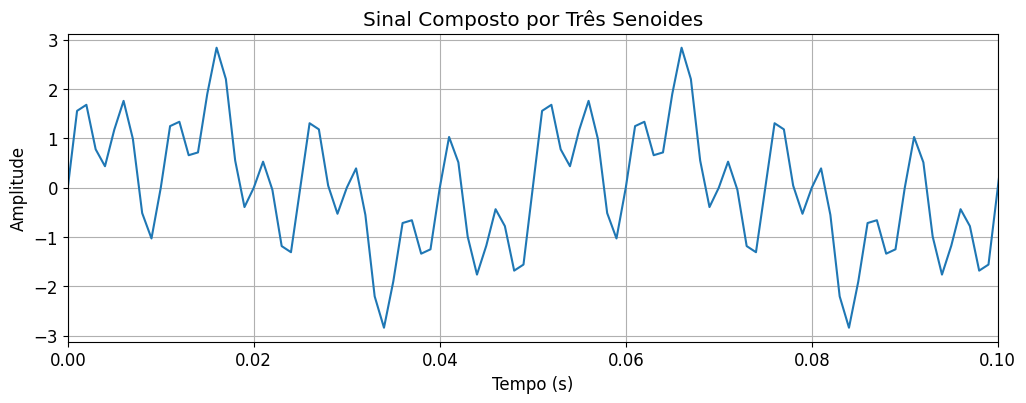

In [41]:
# ============================================================
# Sinal Original
# ============================================================

plt.plot(t, x)

plt.title('Sinal Composto por Três Senoides')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')

plt.xlim(0, 0.1)
plt.grid(True)

plt.show()

In [42]:
# ============================================================
# Projeto do Filtro Passa-Faixa FIR
# ============================================================

f_inferior = 60
f_superior = 100

b = signal.firwin(
    numtaps=101,
    cutoff=[f_inferior, f_superior],
    pass_zero=False,
    fs=fs
)

print('Filtro passa-faixa projetado com sucesso.')

Filtro passa-faixa projetado com sucesso.


In [43]:
# ============================================================
# Aplicação do Filtro
# ============================================================

y = signal.lfilter(
    b,
    1,
    x
)

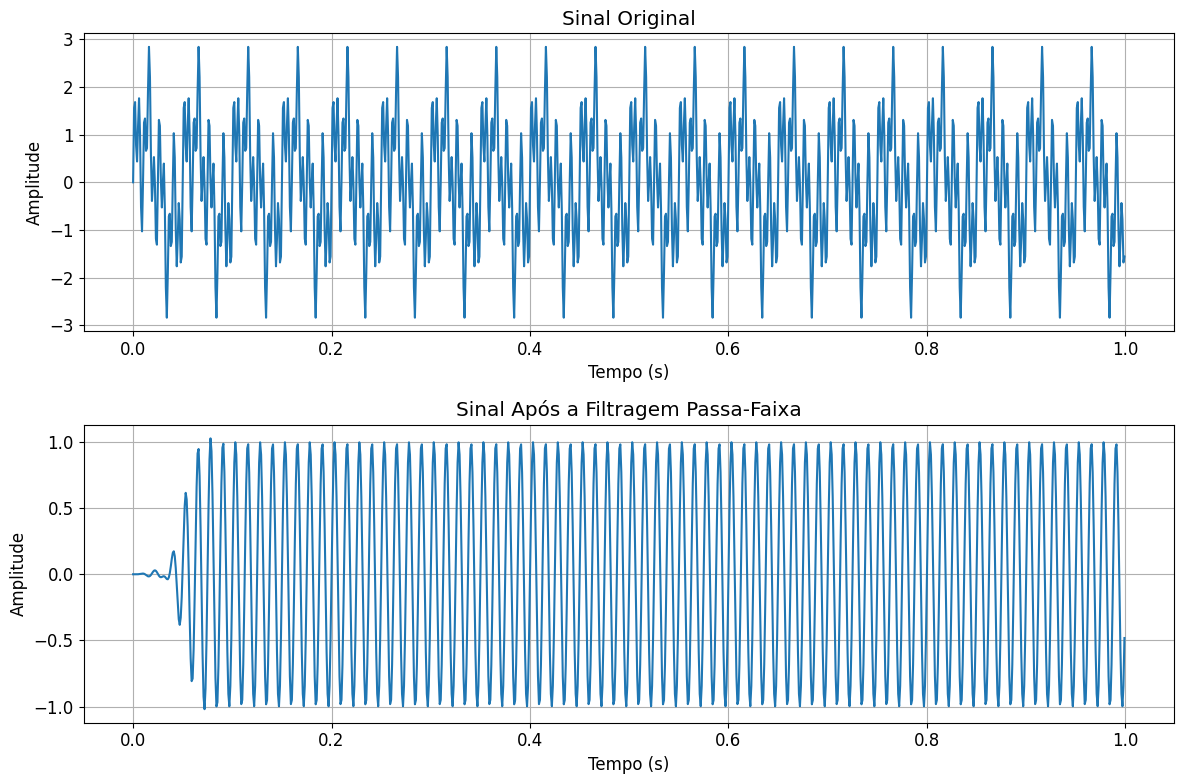

In [44]:
# ============================================================
# Comparação Temporal
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')
ax[0].grid(True)

ax[1].plot(t, y)
ax[1].set_title('Sinal Após a Filtragem Passa-Faixa')
ax[1].grid(True)

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

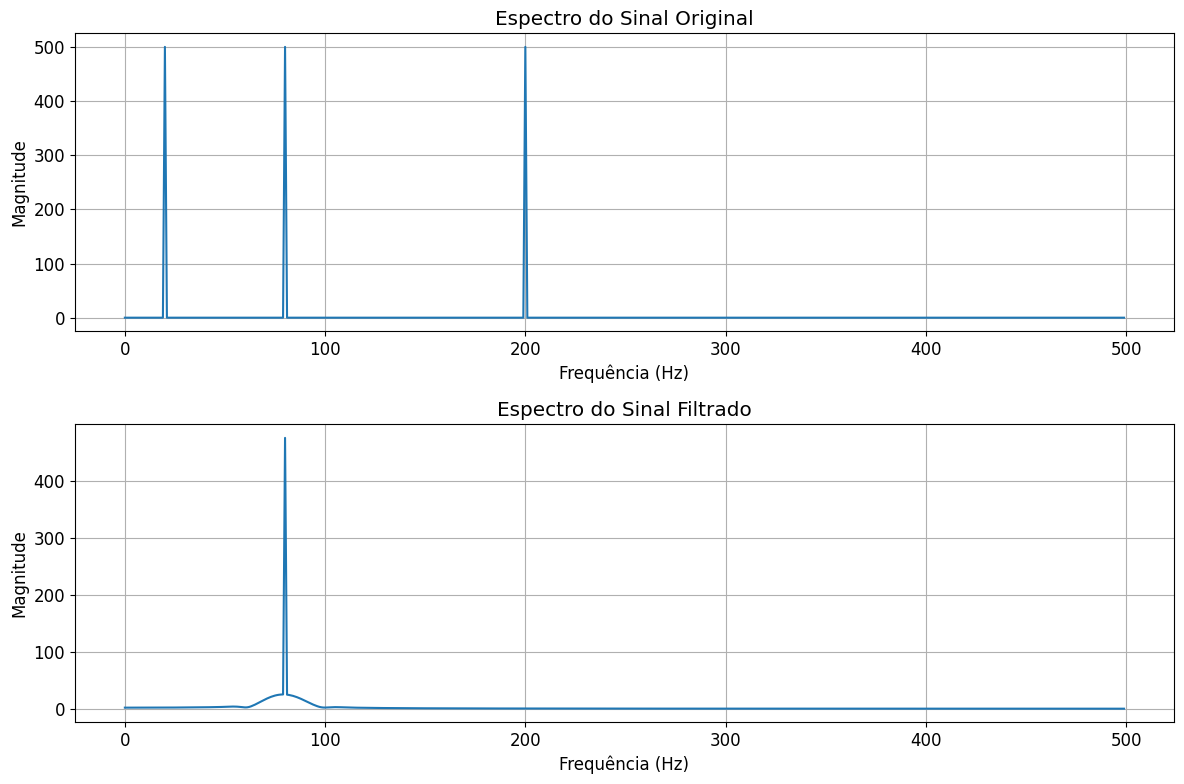

In [45]:
# ============================================================
# Análise Espectral
# ============================================================

N = len(x)

freq = fftfreq(
    N,
    1/fs
)

X = fft(x)
Y = fft(y)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(
    freq[:N//2],
    np.abs(X[:N//2])
)

ax[0].set_title('Espectro do Sinal Original')
ax[0].grid(True)

ax[1].plot(
    freq[:N//2],
    np.abs(Y[:N//2])
)

ax[1].set_title('Espectro do Sinal Filtrado')
ax[1].grid(True)

for eixo in ax:
    eixo.set_xlabel('Frequência (Hz)')
    eixo.set_ylabel('Magnitude')

plt.tight_layout()
plt.show()

## Discussão dos Resultados

O espectro do sinal original apresenta três componentes de frequência localizadas em aproximadamente 20 Hz, 80 Hz e 200 Hz.

Após a aplicação do filtro passa-faixa, observa-se que a componente de aproximadamente 80 Hz permanece praticamente inalterada, enquanto as componentes de 20 Hz e 200 Hz sofrem forte atenuação.

A resposta em frequência do filtro evidencia que o ganho é elevado apenas na faixa compreendida entre 60 Hz e 100 Hz, correspondendo exatamente à banda de passagem especificada durante o projeto do filtro.

No domínio do tempo, o sinal filtrado apresenta comportamento predominantemente senoidal, uma vez que a maior parte de sua energia está agora concentrada em torno da frequência de 80 Hz.

Os resultados demonstram a capacidade dos filtros passa-faixa de realizar seleção espectral de sinais, permitindo isolar componentes específicas presentes em sinais compostos.

## Conclusão

O filtro digital passa-faixa mostrou-se capaz de selecionar apenas a componente espectral localizada na região de interesse, atenuando as demais componentes presentes no sinal.

A atividade permitiu compreender o funcionamento dos filtros passa-faixa, bem como a relação entre sua resposta em frequência e o comportamento observado nos domínios do tempo e da frequência.

Os resultados evidenciam a importância desse tipo de filtragem em aplicações que exigem a identificação ou extração de informações concentradas em faixas específicas do espectro, constituindo uma ferramenta fundamental do Processamento Digital de Sinais.

# Questão 8 – Comparação das Respostas de Fase de Filtros FIR e IIR

## Enunciado

Projete um filtro FIR e um filtro IIR Butterworth para a mesma frequência de corte e compare suas respostas de fase. Analise como a fase influencia a preservação da forma temporal do sinal.

---

## Objetivos da Atividade

- Projetar um filtro FIR passa-baixa;
- Projetar um filtro IIR Butterworth passa-baixa;
- Determinar as respostas de fase de ambos os filtros;
- Comparar os comportamentos de fase dos filtros;
- Relacionar a resposta de fase com a preservação da forma temporal dos sinais;
- Interpretar fisicamente os efeitos da distorção de fase.

---

## Fundamentação Teórica

A resposta em frequência de um sistema linear invariante no tempo é uma função complexa que pode ser representada em termos de magnitude e fase. Enquanto a magnitude descreve como cada componente de frequência é amplificada ou atenuada, a fase descreve o deslocamento angular ou temporal introduzido em cada componente espectral.

Segundo Oppenheim e Schafer, a resposta de fase exerce papel fundamental na preservação da forma temporal dos sinais. Quando diferentes componentes de frequência sofrem deslocamentos temporais distintos, ocorre o fenômeno conhecido como distorção de fase, podendo alterar significativamente a forma do sinal reconstruído.

Os filtros FIR podem ser projetados de maneira a apresentar resposta de fase aproximadamente linear. Nesse caso, todas as componentes espectrais sofrem praticamente o mesmo atraso temporal, preservando a forma original do sinal.

Em contraste, filtros IIR geralmente apresentam respostas de fase não lineares. Como consequência, diferentes frequências são atrasadas de maneira distinta, podendo ocorrer deformações temporais, mesmo quando a resposta em magnitude permanece adequada.

Fisicamente, pode-se interpretar a resposta de fase como um mecanismo que controla o instante em que cada componente senoidal aparece na saída do sistema. Se todas as frequências forem deslocadas igualmente, a forma do sinal é preservada. Caso contrário, as componentes deixam de permanecer sincronizadas, produzindo distorções temporais.

Neste experimento, serão comparadas as respostas de fase de um filtro FIR e de um filtro IIR Butterworth, permitindo analisar a relação entre fase e fidelidade temporal dos sinais processados.

In [46]:
# ============================================================
# Questão 8 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [47]:
# ============================================================
# Projeto dos Filtros
# ============================================================

fs = 1000
fc = 100

# Filtro FIR
b_fir = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

# Filtro IIR Butterworth
ordem = 4

b_iir, a_iir = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

print('Filtros projetados com sucesso.')

Filtros projetados com sucesso.


In [48]:
# ============================================================
# Respostas de Fase
# ============================================================

w_fir, h_fir = signal.freqz(
    b_fir,
    worN=2048,
    fs=fs
)

w_iir, h_iir = signal.freqz(
    b_iir,
    a_iir,
    worN=2048,
    fs=fs
)

fase_fir = np.unwrap(np.angle(h_fir))
fase_iir = np.unwrap(np.angle(h_iir))

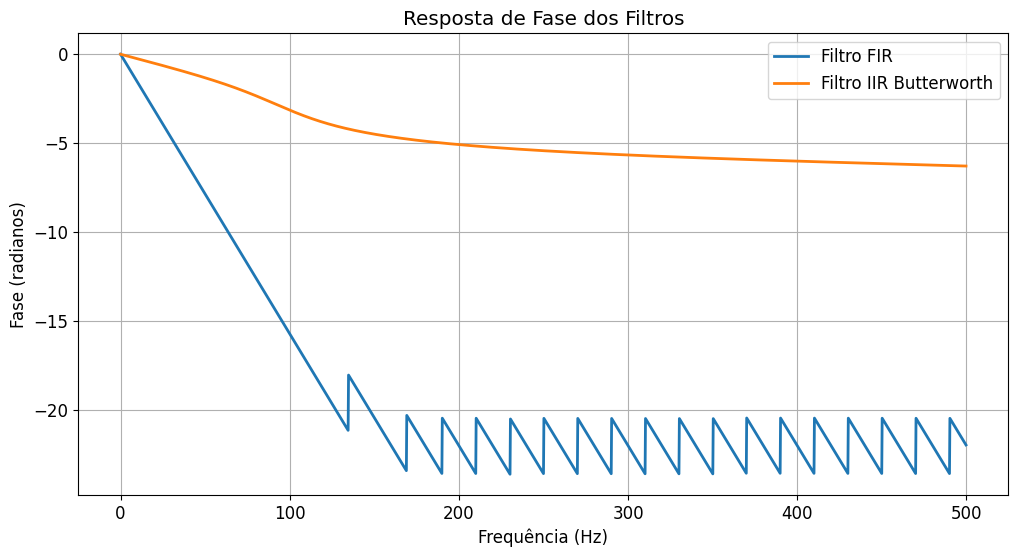

In [49]:
# ============================================================
# Comparação das Respostas de Fase
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    w_fir,
    fase_fir,
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    fase_iir,
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.title('Resposta de Fase dos Filtros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')

plt.grid(True)
plt.legend()

plt.show()

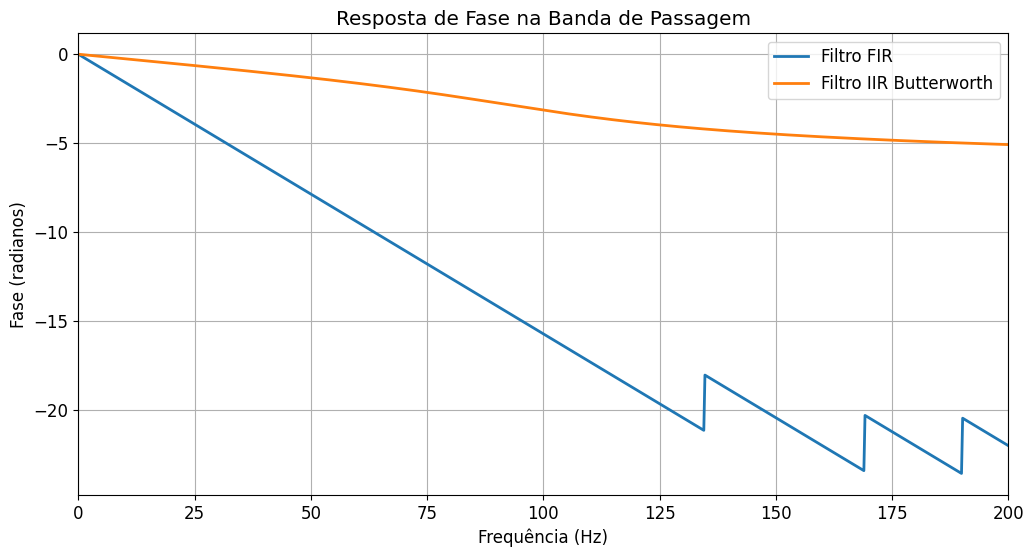

In [50]:
# ============================================================
# Ampliação da Banda de Passagem
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    w_fir,
    fase_fir,
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    fase_iir,
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.xlim(0, 200)

plt.title('Resposta de Fase na Banda de Passagem')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')

plt.grid(True)
plt.legend()

plt.show()

In [51]:
# ============================================================
# Demonstração Temporal
# ============================================================

T = 1
t = np.linspace(0, T, fs, endpoint=False)

x = (
    np.sin(2*np.pi*20*t)
    + np.sin(2*np.pi*80*t)
)

y_fir = signal.lfilter(
    b_fir,
    1,
    x
)

y_iir = signal.lfilter(
    b_iir,
    a_iir,
    x
)

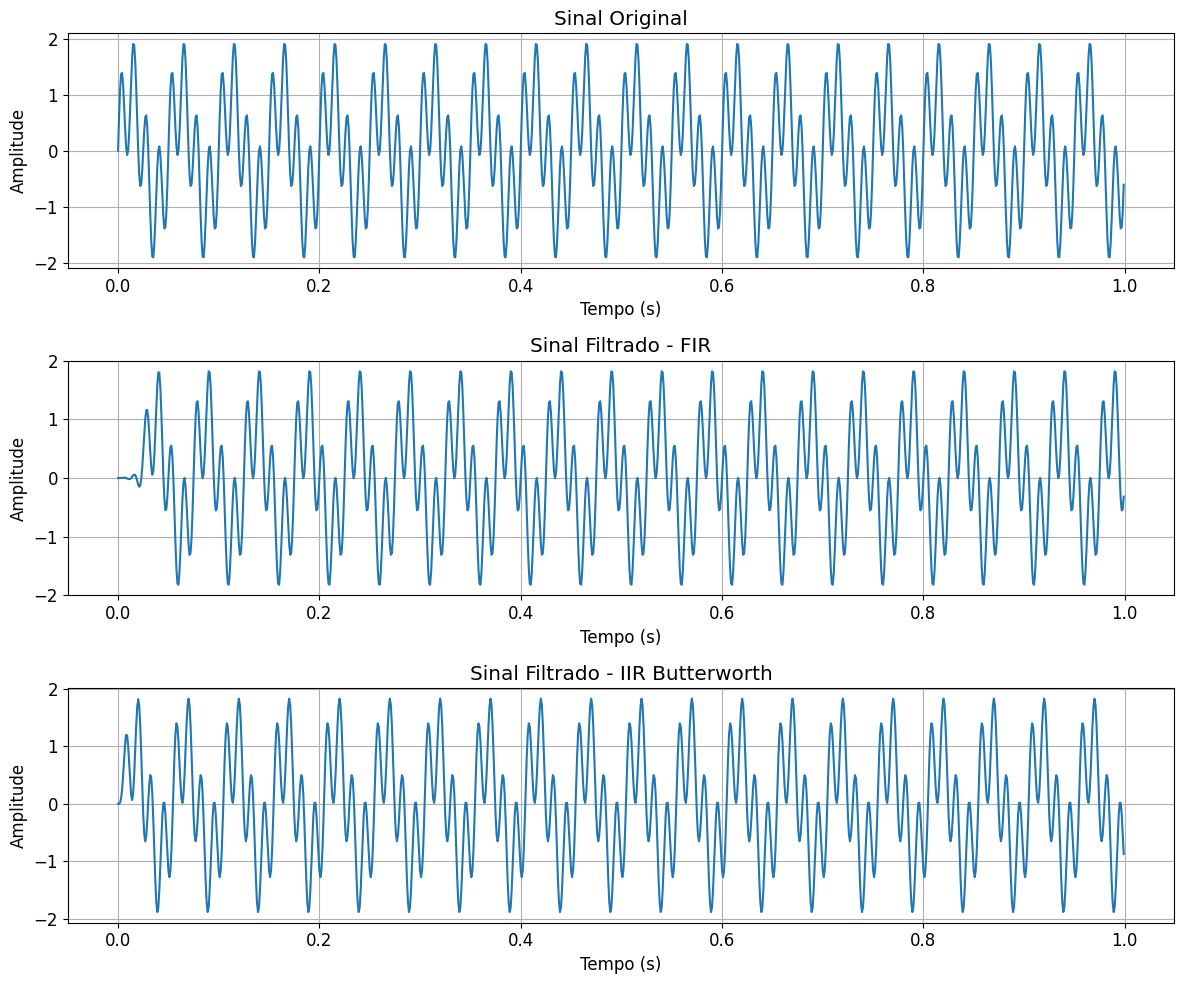

In [52]:
# ============================================================
# Comparação Temporal
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')
ax[0].grid(True)

ax[1].plot(t, y_fir)
ax[1].set_title('Sinal Filtrado - FIR')
ax[1].grid(True)

ax[2].plot(t, y_iir)
ax[2].set_title('Sinal Filtrado - IIR Butterworth')
ax[2].grid(True)

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

## Discussão dos Resultados

Os gráficos obtidos mostram diferenças importantes entre as respostas de fase dos filtros FIR e IIR.

Observa-se que o filtro FIR apresenta uma resposta de fase aproximadamente linear na banda de passagem. Isso significa que as diferentes componentes de frequência sofrem praticamente o mesmo atraso temporal, preservando o alinhamento entre elas.

Por outro lado, o filtro IIR Butterworth apresenta uma resposta de fase não linear. Consequentemente, as componentes espectrais são atrasadas de maneira diferente, produzindo pequenas deformações na forma temporal do sinal.

Embora ambos os filtros apresentem respostas em magnitude adequadas para a tarefa de filtragem, suas respostas de fase são significativamente distintas. Esse resultado demonstra que a qualidade de um sistema de filtragem não depende exclusivamente da atenuação de frequências indesejadas, mas também da capacidade de preservar as relações temporais entre as componentes espectrais.

Em aplicações de áudio, processamento biomédico e instrumentação de precisão, a resposta de fase torna-se um critério de projeto extremamente importante, pois a preservação da forma de onda pode ser tão relevante quanto a própria filtragem espectral.

## Conclusão

A comparação das respostas de fase permitiu verificar que filtros FIR podem apresentar comportamento aproximadamente linear, preservando a forma temporal dos sinais processados.

Em contraste, o filtro IIR Butterworth apresentou uma resposta de fase não linear, introduzindo diferentes atrasos para cada componente espectral.

A atividade evidenciou que a análise de filtros digitais deve considerar simultaneamente magnitude e fase, uma vez que ambas influenciam diretamente a qualidade do sinal obtido na saída do sistema.

Os resultados reforçam a importância da resposta de fase no projeto de sistemas de Processamento Digital de Sinais, especialmente em aplicações que exigem elevada fidelidade temporal.

# Questão 9 – Análise do Atraso de Grupo em Filtros FIR e IIR

## Enunciado

Projete um filtro FIR e um filtro IIR Butterworth para a mesma frequência de corte e determine seus atrasos de grupo. Compare os resultados e analise a influência do atraso de grupo na preservação da forma temporal dos sinais.

---

## Objetivos da Atividade

- Projetar um filtro FIR passa-baixa;
- Projetar um filtro IIR Butterworth passa-baixa;
- Determinar o atraso de grupo de ambos os filtros;
- Comparar os comportamentos de atraso de grupo;
- Relacionar o atraso de grupo com a resposta de fase;
- Interpretar os efeitos do atraso de grupo sobre a forma temporal dos sinais.

---

## Fundamentação Teórica

A resposta em fase de um sistema linear invariante no tempo descreve o deslocamento angular introduzido em cada componente espectral do sinal. Entretanto, em muitas aplicações práticas, torna-se mais conveniente analisar diretamente o deslocamento temporal das diferentes frequências.

Para esse propósito, utiliza-se o conceito de atraso de grupo (Group Delay), definido como a taxa de variação da fase em relação à frequência angular. Matematicamente, o atraso de grupo é expresso por:

τg(ω) = - dφ(ω) / dω

onde:

- τg(ω) representa o atraso de grupo;
- φ(ω) é a resposta de fase do sistema;
- ω corresponde à frequência angular.

Segundo Oppenheim e Schafer, o atraso de grupo fornece uma medida direta de quanto cada componente espectral é retardada ao atravessar o sistema.

Quando o atraso de grupo permanece aproximadamente constante ao longo da banda de passagem, todas as componentes espectrais sofrem praticamente o mesmo deslocamento temporal. Como consequência, a forma do sinal é preservada.

Por outro lado, quando diferentes frequências apresentam atrasos distintos, ocorre dispersão temporal. Nesse caso, as componentes deixam de permanecer sincronizadas, podendo produzir deformações na forma do sinal reconstruído.

Os filtros FIR de fase aproximadamente linear apresentam atraso de grupo praticamente constante, sendo frequentemente empregados em aplicações que exigem elevada fidelidade temporal. Em contraste, filtros IIR normalmente apresentam atraso de grupo variável, consequência direta de sua resposta de fase não linear.

Fisicamente, o atraso de grupo pode ser interpretado como o tempo necessário para que a informação associada a uma determinada frequência atravesse o sistema. Quanto mais uniforme for esse atraso entre as diversas componentes espectrais, maior será a preservação da estrutura temporal do sinal.

Neste experimento, serão comparados os atrasos de grupo de um filtro FIR e de um filtro IIR Butterworth, permitindo compreender quantitativamente as diferenças observadas em suas respostas de fase.

In [53]:
# ============================================================
# Questão 9 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [54]:
# ============================================================
# Projeto dos Filtros
# ============================================================

fs = 1000
fc = 100

# Filtro FIR
b_fir = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

# Filtro IIR Butterworth
ordem = 4

b_iir, a_iir = signal.butter(
    ordem,
    fc,
    btype='low',
    fs=fs
)

print('Filtros projetados com sucesso.')

Filtros projetados com sucesso.


In [55]:
# ============================================================
# Atraso de Grupo
# ============================================================

w_fir, gd_fir = signal.group_delay(
    (b_fir, 1),
    fs=fs
)

w_iir, gd_iir = signal.group_delay(
    (b_iir, a_iir),
    fs=fs
)

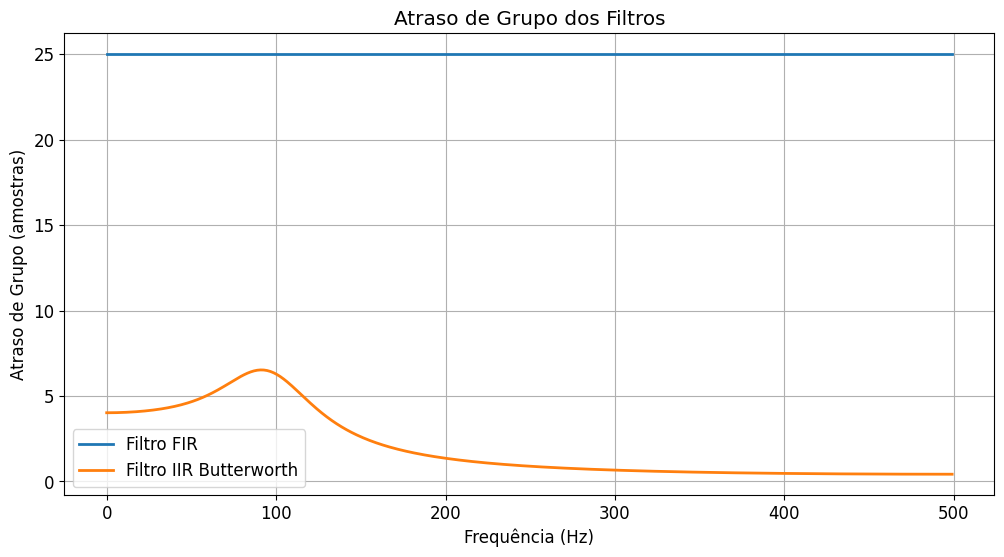

In [56]:
# ============================================================
# Comparação dos Atrasos de Grupo
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    w_fir,
    gd_fir,
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    gd_iir,
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.title('Atraso de Grupo dos Filtros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Atraso de Grupo (amostras)')

plt.grid(True)
plt.legend()

plt.show()

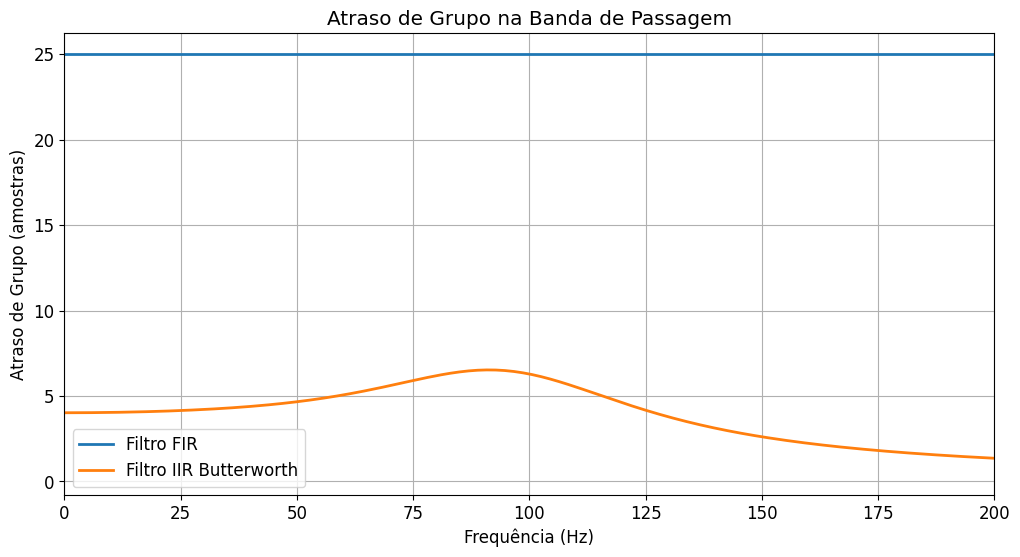

In [57]:
# ============================================================
# Região da Banda de Passagem
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    w_fir,
    gd_fir,
    linewidth=2,
    label='Filtro FIR'
)

plt.plot(
    w_iir,
    gd_iir,
    linewidth=2,
    label='Filtro IIR Butterworth'
)

plt.xlim(0, 200)

plt.title('Atraso de Grupo na Banda de Passagem')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Atraso de Grupo (amostras)')

plt.grid(True)
plt.legend()

plt.show()

In [58]:
# ============================================================
# Demonstração Temporal
# ============================================================

T = 1
t = np.linspace(0, T, fs, endpoint=False)

x = (
    np.sin(2*np.pi*20*t)
    + np.sin(2*np.pi*80*t)
)

y_fir = signal.lfilter(
    b_fir,
    1,
    x
)

y_iir = signal.lfilter(
    b_iir,
    a_iir,
    x
)

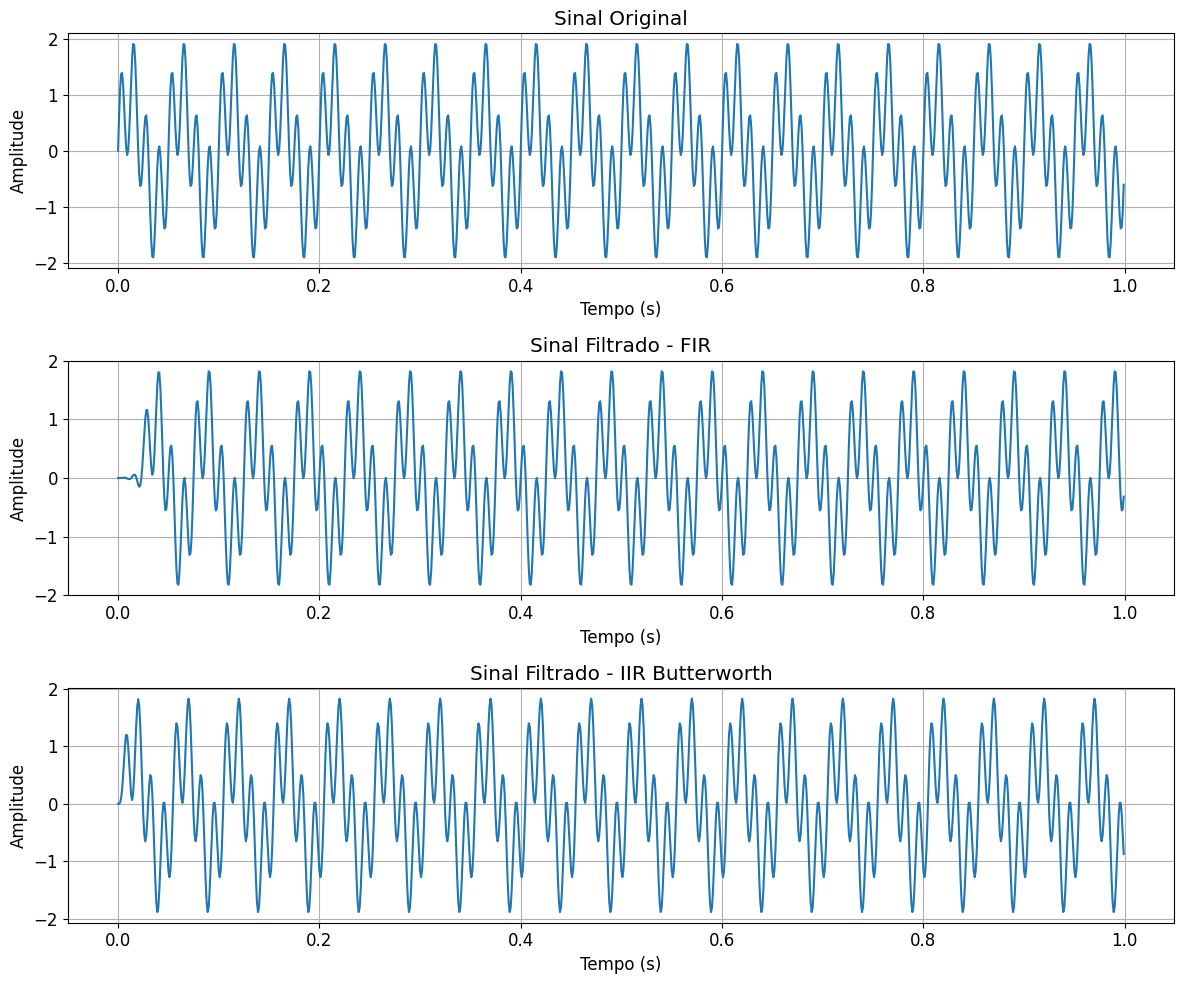

In [59]:
# ============================================================
# Comparação Temporal
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')
ax[0].grid(True)

ax[1].plot(t, y_fir)
ax[1].set_title('Sinal Filtrado - FIR')
ax[1].grid(True)

ax[2].plot(t, y_iir)
ax[2].set_title('Sinal Filtrado - IIR Butterworth')
ax[2].grid(True)

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

## Discussão dos Resultados

Os resultados obtidos mostram diferenças importantes entre os atrasos de grupo dos filtros analisados.

O filtro FIR apresenta atraso de grupo praticamente constante na banda de passagem. Isso significa que todas as componentes espectrais são retardadas aproximadamente pelo mesmo número de amostras, preservando o alinhamento temporal entre as frequências presentes no sinal.

Por outro lado, o filtro IIR Butterworth apresenta atraso de grupo variável ao longo da banda de passagem. Como consequência, diferentes componentes de frequência experimentam atrasos distintos, produzindo dispersão temporal.

Essa diferença explica os resultados observados na Questão 8. Embora ambos os filtros apresentem respostas em magnitude adequadas, apenas o filtro FIR mantém praticamente inalterada a estrutura temporal do sinal.

Fisicamente, o atraso de grupo representa o tempo necessário para que cada componente de frequência atravesse o sistema. Quando esse atraso é uniforme, a informação espectral permanece sincronizada. Quando o atraso varia com a frequência, ocorre distorção temporal, podendo alterar a forma de onda do sinal processado.

## Conclusão

A análise do atraso de grupo permitiu compreender quantitativamente as diferenças entre filtros FIR e IIR.

O filtro FIR apresentou atraso de grupo aproximadamente constante, característica diretamente associada à sua resposta de fase quase linear e à preservação da forma temporal dos sinais.

Em contraste, o filtro IIR Butterworth apresentou atraso de grupo variável, consequência de sua resposta de fase não linear, podendo introduzir dispersão temporal entre as componentes espectrais.

A atividade demonstrou que o atraso de grupo constitui um importante critério de projeto em Processamento Digital de Sinais, especialmente em aplicações nas quais a fidelidade temporal do sinal é tão importante quanto sua filtragem espectral.

# Questão 10 – Aplicação Integrada de Filtros Digitais na Separação de Componentes Espectrais

## Enunciado

Considere um sinal composto por uma componente de baixa frequência, representando a informação de interesse, e uma componente de alta frequência, representando uma interferência indesejada. Projete um filtro digital adequado para recuperar o sinal útil e analise os resultados obtidos nos domínios do tempo e da frequência.

---

## Objetivos da Atividade

- Gerar um sinal composto por informação útil e interferência;
- Projetar um filtro digital para separar as componentes espectrais;
- Aplicar o filtro ao sinal composto;
- Comparar os sinais antes e após a filtragem;
- Analisar os resultados nos domínios do tempo e da frequência;
- Integrar os conceitos estudados ao longo do estudo dirigido.

---

## Fundamentação Teórica

Um dos principais objetivos do Processamento Digital de Sinais consiste em extrair informações relevantes de sinais contaminados por componentes indesejadas. Em diversas aplicações reais, os sinais adquiridos pelos sistemas de medição são compostos pela superposição de informações úteis, ruídos e interferências de diferentes origens.

Segundo Oppenheim e Schafer, a representação de sinais no domínio da frequência permite identificar e separar componentes espectrais que se encontram sobrepostas no domínio do tempo. Essa propriedade torna a filtragem digital uma ferramenta fundamental em sistemas de aquisição e processamento de dados.

Quando a informação útil está concentrada em uma determinada faixa de frequências, torna-se possível projetar filtros capazes de preservar essas componentes enquanto atenuam sinais indesejados localizados em outras regiões do espectro.

Fisicamente, um filtro digital pode ser interpretado como um mecanismo seletivo de frequências, permitindo a passagem das componentes de interesse e reduzindo a influência de interferências presentes no sinal.

Em aplicações de telecomunicações, sistemas biomédicos, instrumentação eletrônica e monitoramento ambiental, técnicas de filtragem digital são amplamente empregadas para melhorar a qualidade dos sinais observados e aumentar a confiabilidade das informações extraídas.

Neste experimento, será considerado um cenário semelhante ao encontrado em sistemas reais de monitoramento, no qual um sinal útil de baixa frequência encontra-se contaminado por uma componente de alta frequência. Um filtro digital será então projetado para recuperar a informação desejada e permitir a análise completa do processo de filtragem.

In [60]:
# ============================================================
# Questão 10 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [61]:
# ============================================================
# Questão 10 - Bibliotecas
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [62]:
# ============================================================
# Geração do Sinal
# ============================================================

fs = 1000
T = 1

t = np.linspace(0, T, fs, endpoint=False)

f_util = 15
f_interferencia = 150

sinal_util = np.sin(
    2*np.pi*f_util*t
)

interferencia = 0.5 * np.sin(
    2*np.pi*f_interferencia*t
)

x = sinal_util + interferencia

print(f'Componente útil: {f_util} Hz')
print(f'Interferência: {f_interferencia} Hz')

Componente útil: 15 Hz
Interferência: 150 Hz


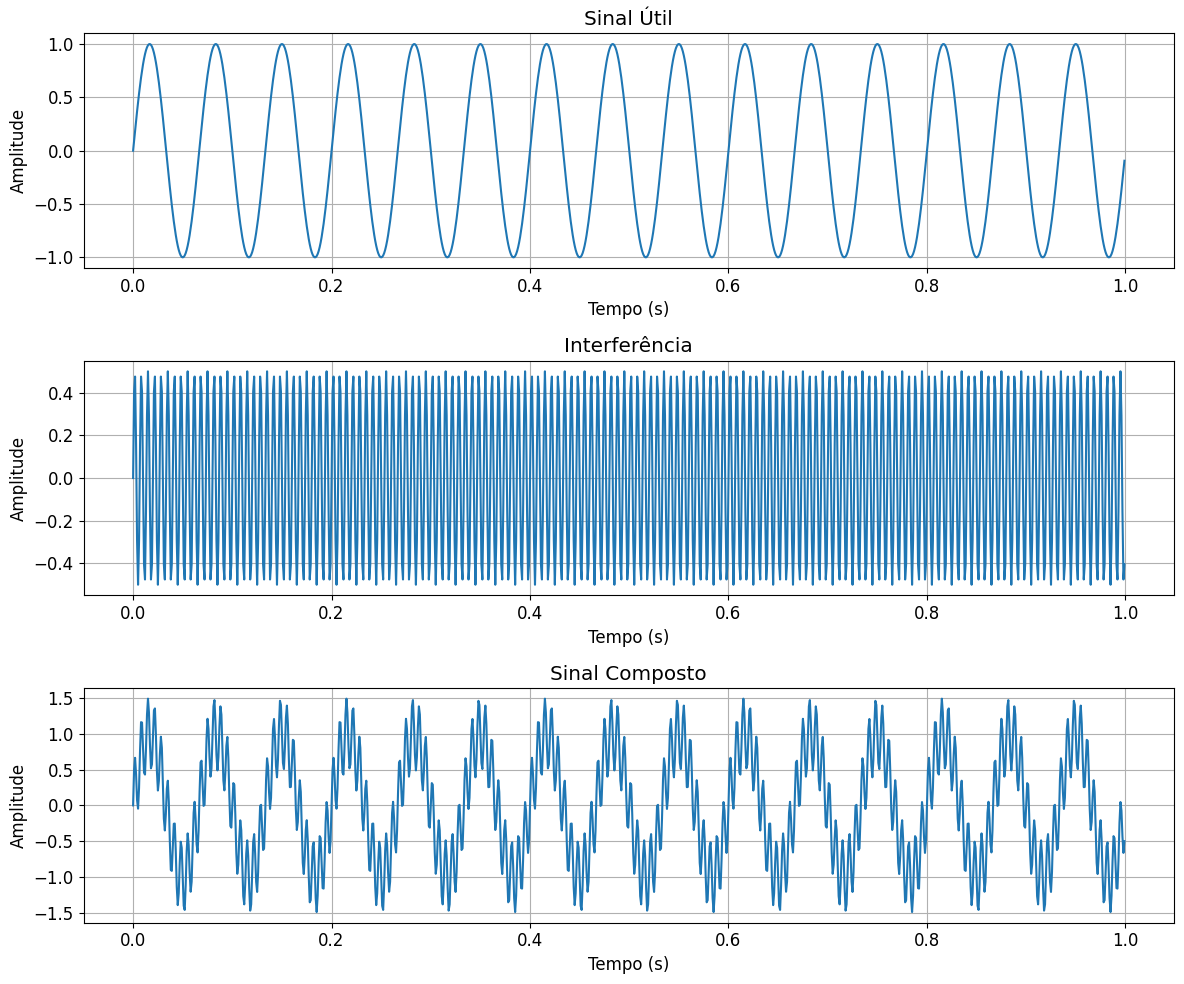

In [63]:
# ============================================================
# Domínio do Tempo
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, sinal_util)
ax[0].set_title('Sinal Útil')

ax[1].plot(t, interferencia)
ax[1].set_title('Interferência')

ax[2].plot(t, x)
ax[2].set_title('Sinal Composto')

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')
    eixo.grid(True)

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# Projeto do Filtro FIR
# ============================================================

fc = 50

b = signal.firwin(
    numtaps=51,
    cutoff=fc,
    fs=fs
)

print('Filtro projetado com sucesso.')

Filtro projetado com sucesso.


In [65]:
# ============================================================
# Aplicação do Filtro
# ============================================================

y = signal.lfilter(
    b,
    1,
    x
)

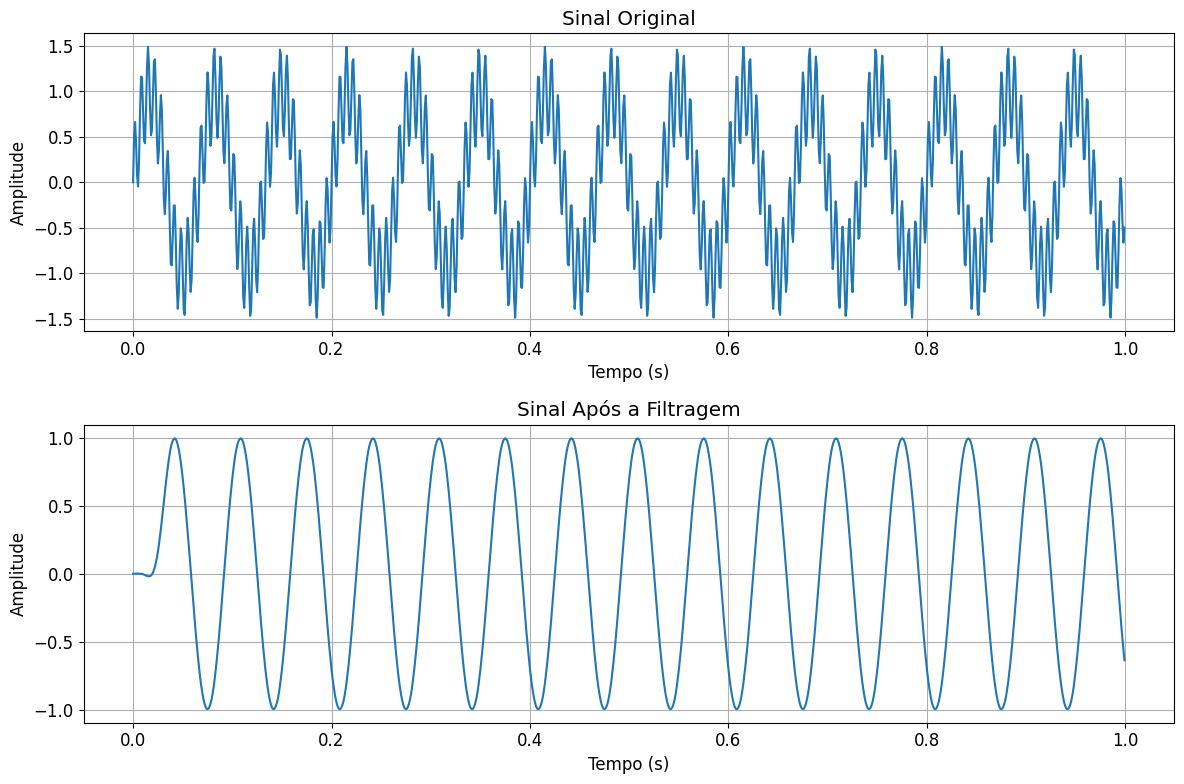

In [66]:
# ============================================================
# Comparação Temporal
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(t, x)
ax[0].set_title('Sinal Original')

ax[1].plot(t, y)
ax[1].set_title('Sinal Após a Filtragem')

for eixo in ax:
    eixo.set_xlabel('Tempo (s)')
    eixo.set_ylabel('Amplitude')
    eixo.grid(True)

plt.tight_layout()
plt.show()

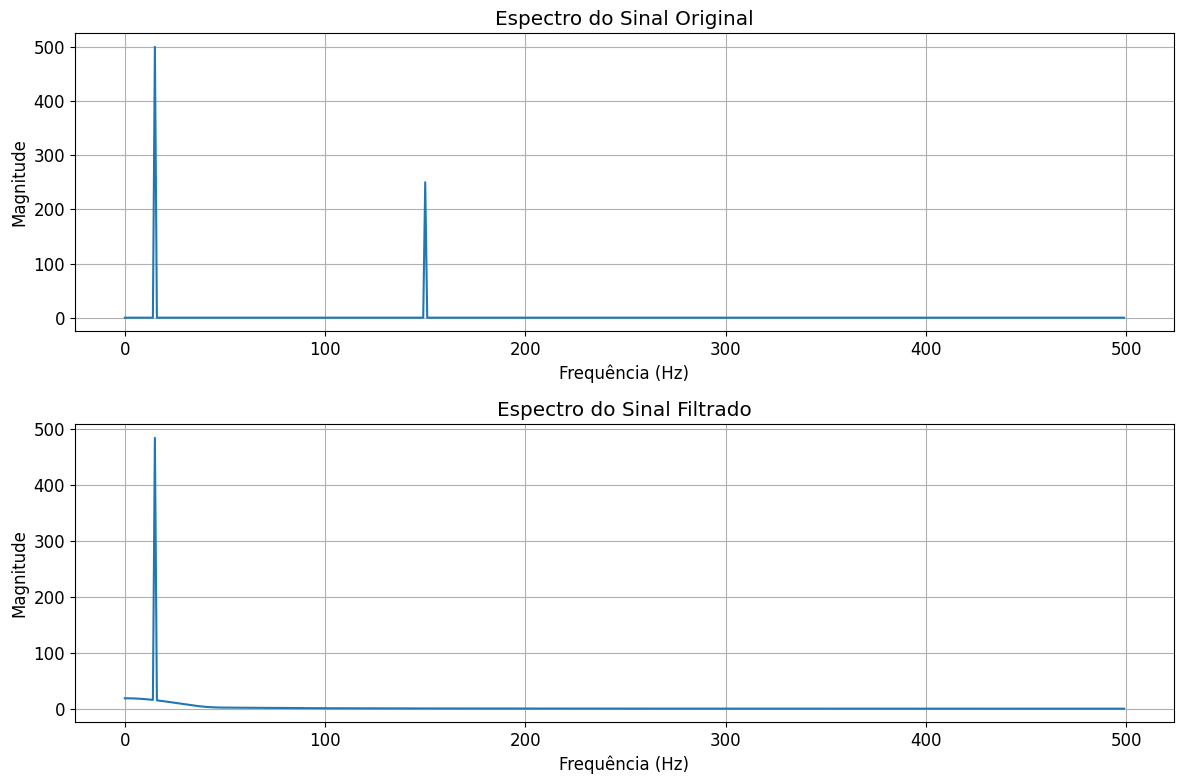

In [67]:
# ============================================================
# Análise Espectral
# ============================================================

N = len(t)

freq = fftfreq(
    N,
    1/fs
)

X = fft(x)
Y = fft(y)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(
    freq[:N//2],
    np.abs(X[:N//2])
)

ax[0].set_title('Espectro do Sinal Original')

ax[1].plot(
    freq[:N//2],
    np.abs(Y[:N//2])
)

ax[1].set_title('Espectro do Sinal Filtrado')

for eixo in ax:
    eixo.set_xlabel('Frequência (Hz)')
    eixo.set_ylabel('Magnitude')
    eixo.grid(True)

plt.tight_layout()
plt.show()

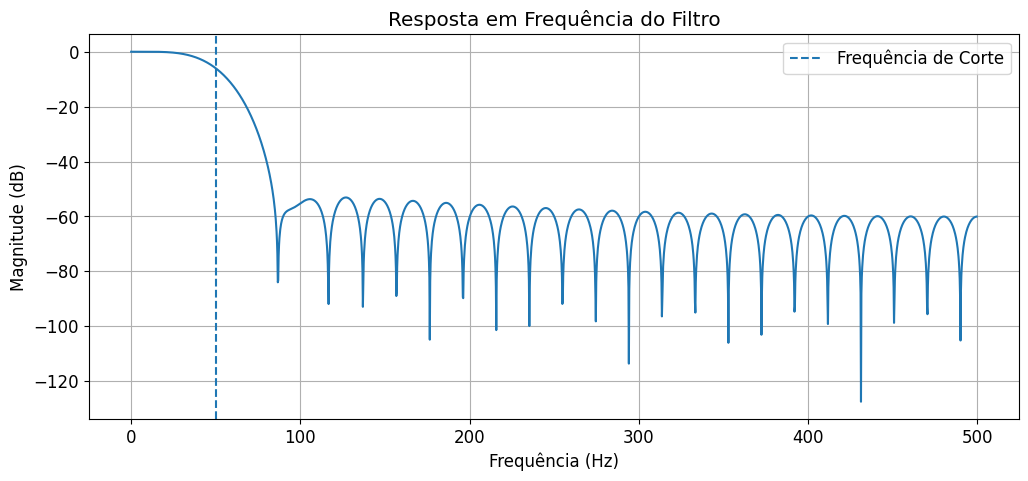

In [68]:
# ============================================================
# Resposta em Frequência
# ============================================================

w, h = signal.freqz(
    b,
    worN=2048,
    fs=fs
)

plt.figure(figsize=(12,5))

plt.plot(
    w,
    20*np.log10(np.abs(h)+1e-10)
)

plt.axvline(
    fc,
    linestyle='--',
    label='Frequência de Corte'
)

plt.title('Resposta em Frequência do Filtro')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')

plt.grid(True)
plt.legend()

plt.show()

## Discussão dos Resultados

O sinal original é composto por duas componentes espectrais distintas: uma senoide de baixa frequência, representando a informação útil, e uma senoide de alta frequência, representando uma interferência indesejada.

A análise espectral evidencia claramente a presença das componentes em aproximadamente 15 Hz e 150 Hz.

Após a aplicação do filtro passa-baixa, observa-se que a componente de 15 Hz é preservada, enquanto a componente de 150 Hz sofre forte atenuação. Como consequência, o sinal filtrado apresenta comportamento temporal bastante semelhante ao sinal útil originalmente gerado.

Os resultados demonstram a capacidade da filtragem digital em realizar separação espectral e recuperação de informações de interesse presentes em sinais compostos.

A atividade integra diversos conceitos estudados ao longo do estudo dirigido, incluindo resposta em frequência, seletividade espectral, filtros FIR, análise temporal e análise espectral.

## Conclusão

A atividade permitiu aplicar de forma integrada os principais conceitos de Processamento Digital de Sinais estudados ao longo deste estudo dirigido.

O filtro digital projetado mostrou-se capaz de recuperar a componente de interesse e reduzir significativamente a interferência presente no sinal composto.

Os resultados obtidos evidenciam a importância da filtragem digital em aplicações práticas de engenharia, nas quais a separação entre informação útil e componentes indesejadas constitui uma etapa fundamental para análise, monitoramento e tomada de decisão.

Além disso, a atividade demonstrou que a combinação entre análise no domínio do tempo e no domínio da frequência fornece uma compreensão completa do comportamento dos sistemas de filtragem digital.